# Модель поведенческого скринга для прогноза просрочек по кредитам 

---
# Описание

### Общая информация
- заказчик проекта: крупный розничный банк
- Массовые просрочки по кредитным платежам могут запустить цепную реакцию: рост резервов -> снижение ликвидности -> риск закрытия банка.

### Бизнес задача
- разработать инструмент прогноза просрочек платежей, опираясь на текущее поведение клиентов. Точный прогноз просрочек платежа позволяет управлять ликвидностью, то есть сглаживать резкие колебания.

### Цель
- разработать модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц предсказывает вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней.

### ML задача

Вид задачи:
- тип: обучение с учителем
- подтип: классификация

Целевая переменная:
- целевая переменная — столбец, содержащий данные о том, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев
- бинарный признак: 1 - просрочка была, 0 - просрочки не было. Строится по принципу скользящего окна

Особенности:
- необходимо использовать горизонт прогноза 12 месяцев
- Объект моделирования — это клиент в конкретный месяц
- У одного и того же клиента значения целевой переменной могут различаться от месяца к месяцу. Даже если клиент ранее уже был в дефолте, в следующие месяцы он мог выплатить долг и вернуться к значению 0 целевой переменной

Ключевые метрики:
- Approval rate, «уровень одобрения» = $\frac{FN + TN}{N}$
- Default rate, «доля просрочек платежа» = $\frac{FN}{FN + TN}$
- Missed defaults rate, «доля пропущенных дефолтов» = $\frac{FN}{FN + TP} = 1 - Recall$ 


Требования по качеству модели:
- Approval rate не менее 65%
- Default rate не более 2%
- Missed defaults rate не более 4%

---
## 1. Настройка проекта и загрузка данных

In [193]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import requests
import warnings
from phik import phik_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from typing import Optional, Union, Dict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import optuna 
from datetime import datetime, timedelta
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
) 
from sklearn.metrics import brier_score_loss
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### Загрузка данных

In [4]:
# пути к файлам
path_s: list[str] = [
    'https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv',
    'https://code.s3.yandex.net/datasets/ds_15_transactions.csv',
    'https://code.s3.yandex.net/datasets/ds_15_client_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv',
    'https://code.s3.yandex.net/datasets/ds_15_macro_data.csv',
    'https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv',
]

In [5]:
def show_info(df) -> None:
    """отображение базовой информации о датасете"""

    display(df.info(), df.head(5))

In [6]:
df_list = [
    pd.read_csv(path) for path in path_s
]

In [7]:
for df in df_list:
    show_info(df) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB


None

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), object(2)
memory usage: 44.1+ MB


None

...

None

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


None

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [8]:
df_names = [
    'loan_payment_credit',
    'transactions',
    'client_description',
    'credit_description',
    'mortgage_presence',
    'credit_rating',
    'macro_data',
    'cohort_grid',
]

Итог:
- загрузка данных прошла корректно: типы данных соответствуют описанию

Анализ:
- данные содержат временные ряды. При дальнейшем анализе важно сохранять сортировку по датам 
- для макроэкономических показателей объединение будет проходить по дате. Для остальных таблиц объединение возможно по ID клиентов. 
- явных пропусков в данных нет


---
## 2. Исследовательский анализ данных


In [9]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [10]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

### Анализ таблиц 

- размеры, типы данных, пропуски, дубли

In [11]:
for name, data_frame in zip(df_names, df_list):
    get_base_df_info(name=name, df=data_frame)

Общая информация о датафрейме loan_payment_credit


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


,Метрика,Значение
0,Строк,5500.0
1,Колонок,3.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,2.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,5500
дата_начала_периода,object,0,0.0,73
просрочка_дней,int64,0,0.0,71


...

Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,13500
score_date,object,0,0.0,84


Типы колонок


,Категориальные колонки,Числовые колонки
0,ID,NaN
1,score_date,NaN


--------------------------------------------------


Анализ:
- в таблице по наличию ипотеки все 6609 значения константные и равны 1. При объединении будем предполагать, что у остальных этот признак равен 0 (то есть ипотеки нет)
- данные не содержат дублей и пропусков

### Анализ распределений 

#### Числовые данные

In [12]:
def plot_hist_box(
    df: pd.DataFrame, feature_name: str,
    df_name: str,
    x_label: str = 'значение',
):
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0])
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1], label=f"{df[feature_name].describe()}")
    axes[0].set_title(f'Распределение признака {feature_name} в датасете {df_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    axes[1].legend(fontsize="x-small", loc='upper right')
    plt.show()

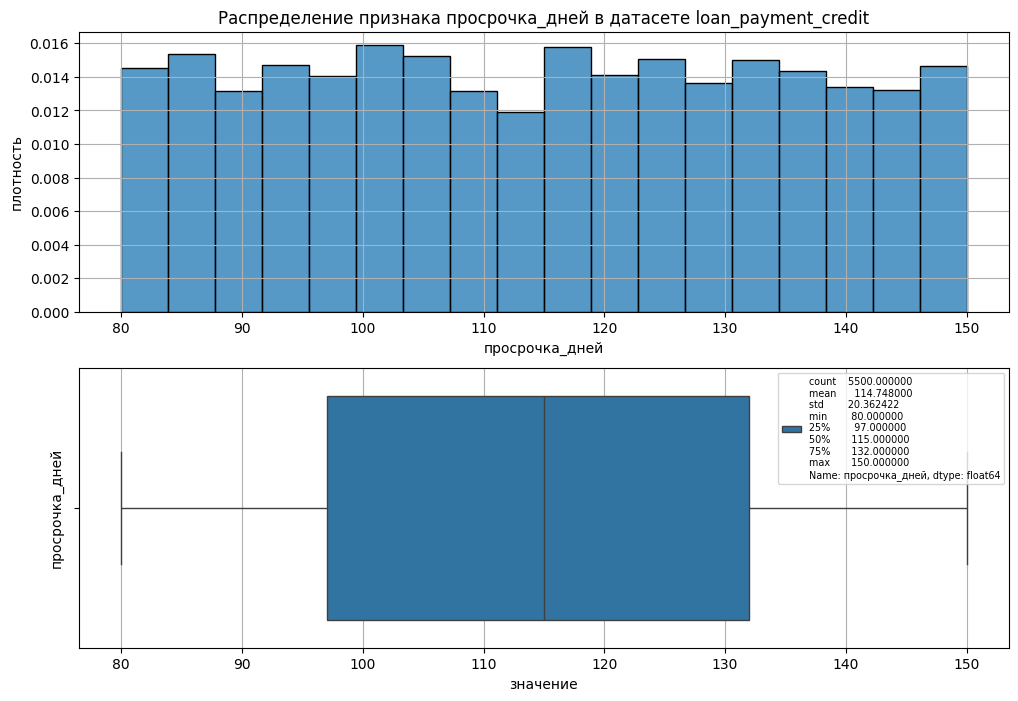

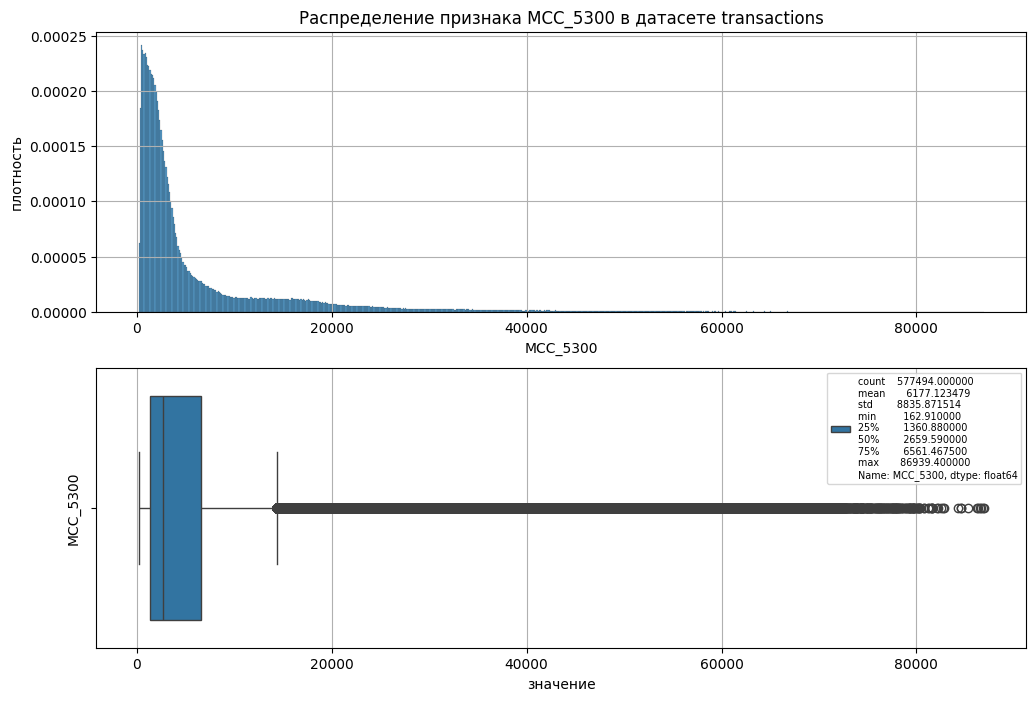

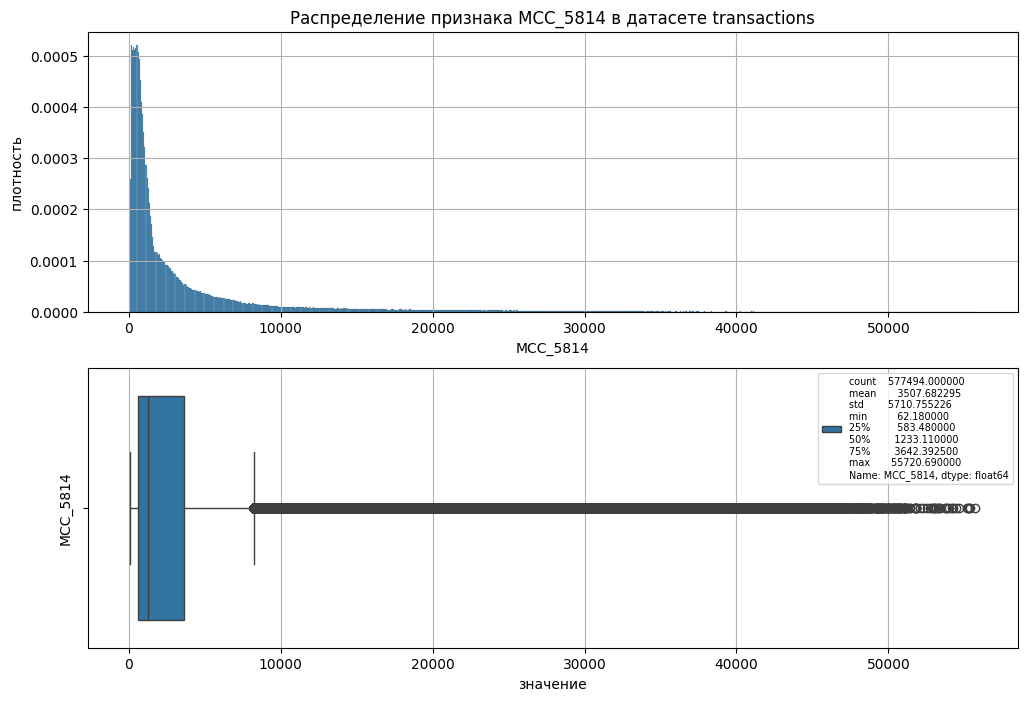

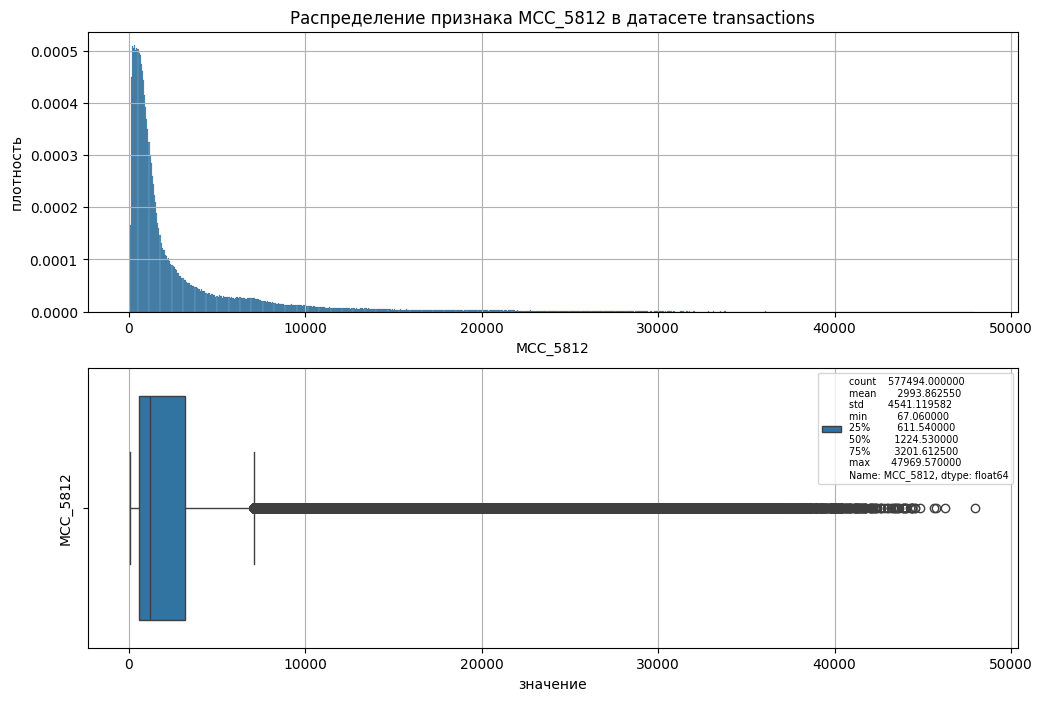

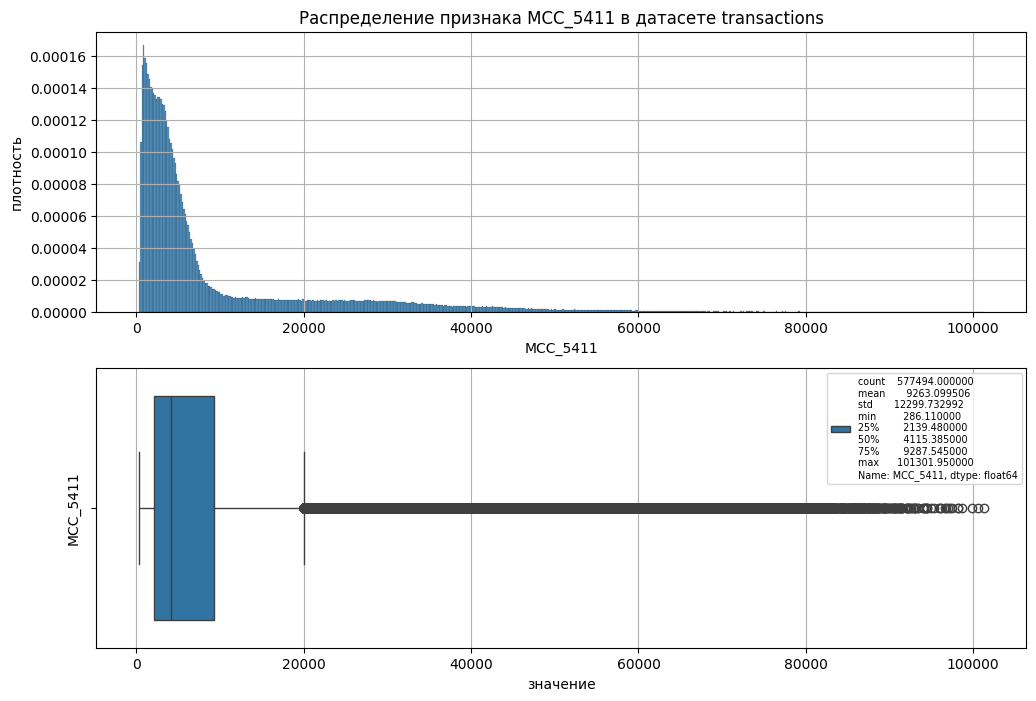

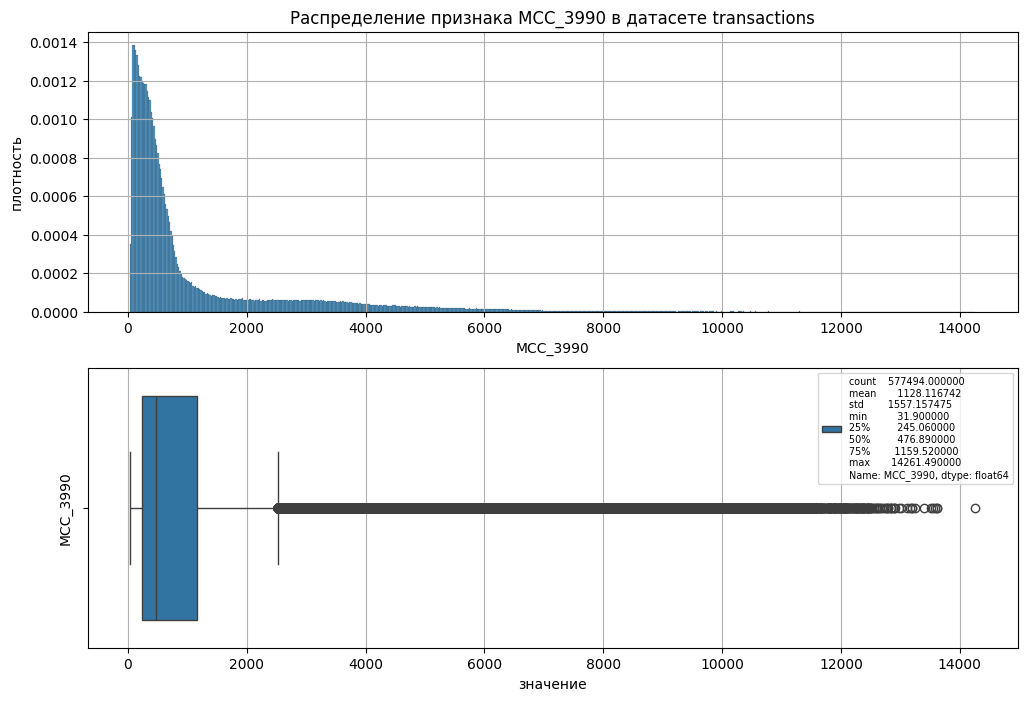

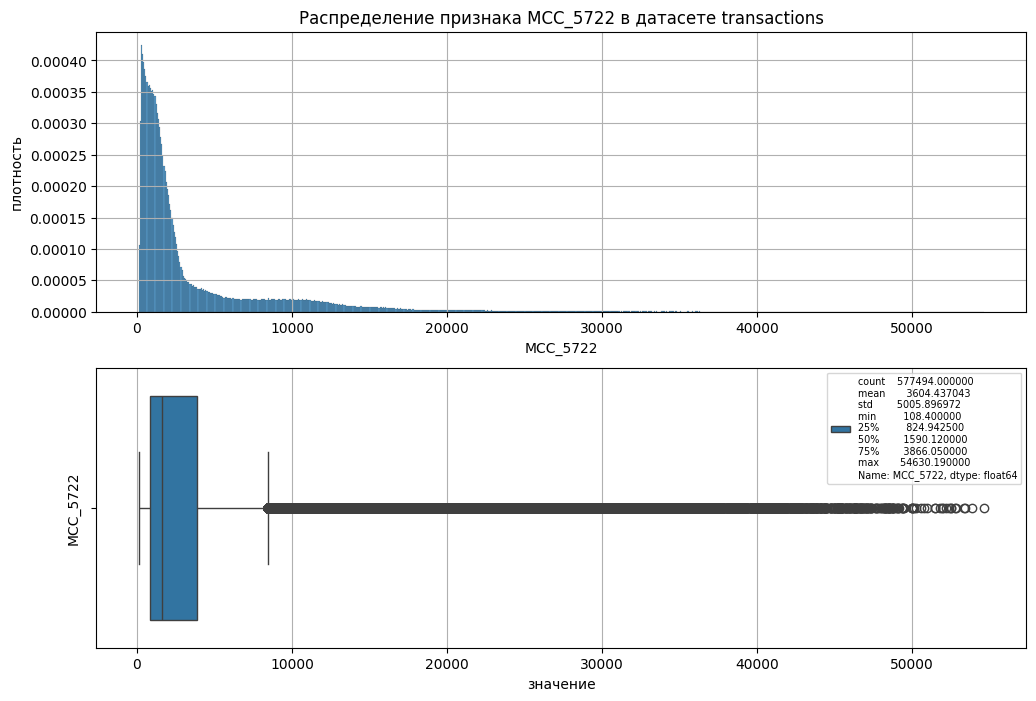

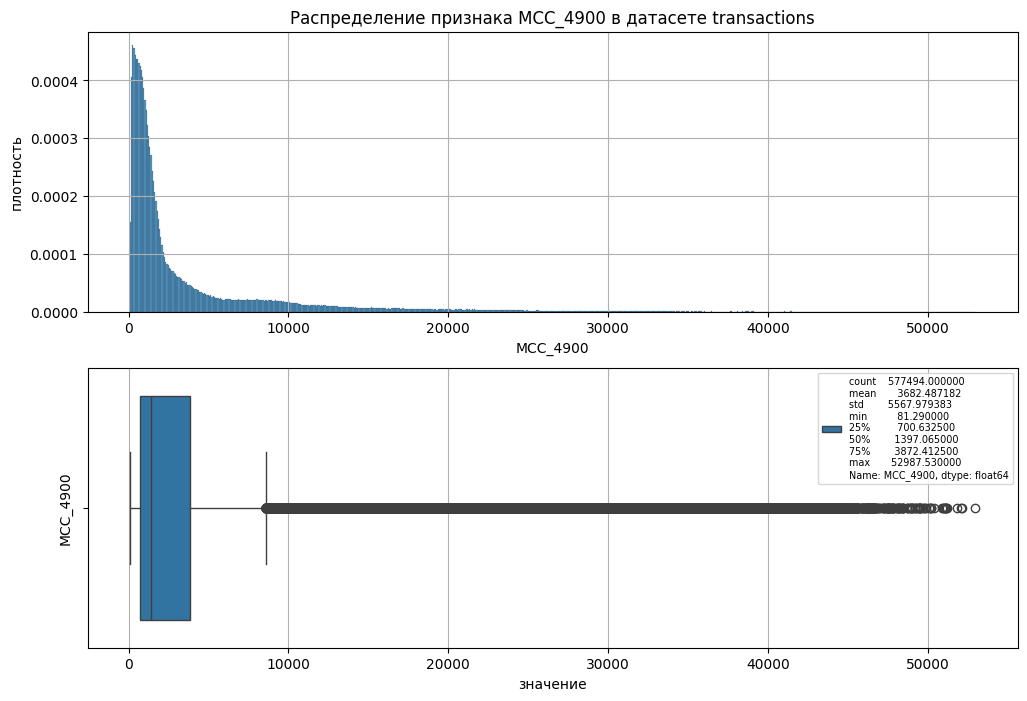

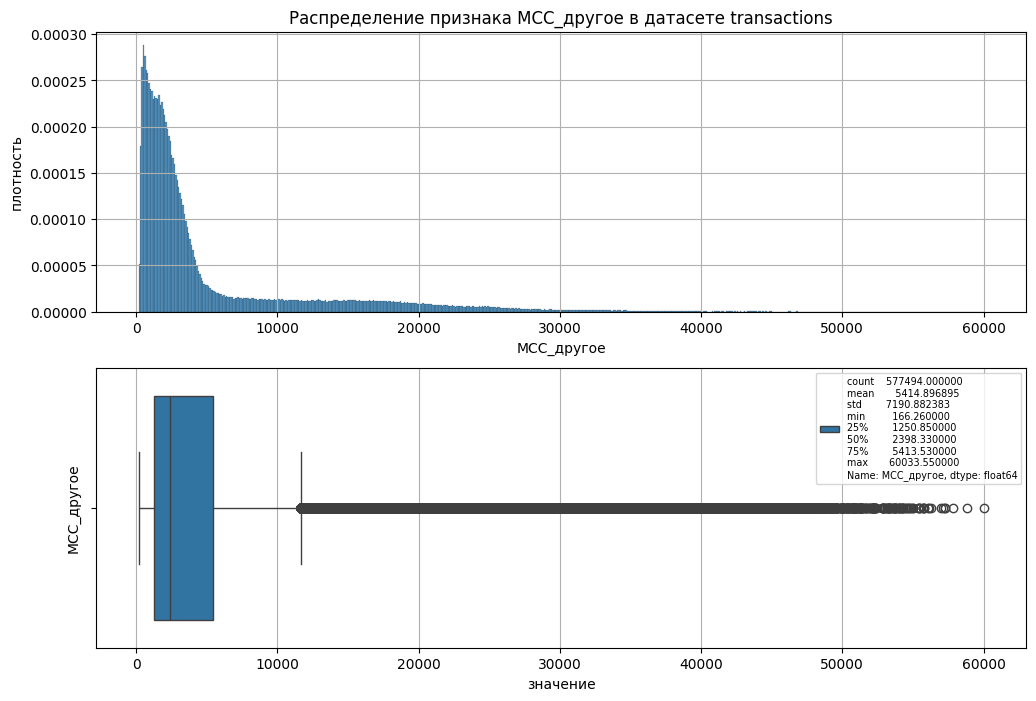

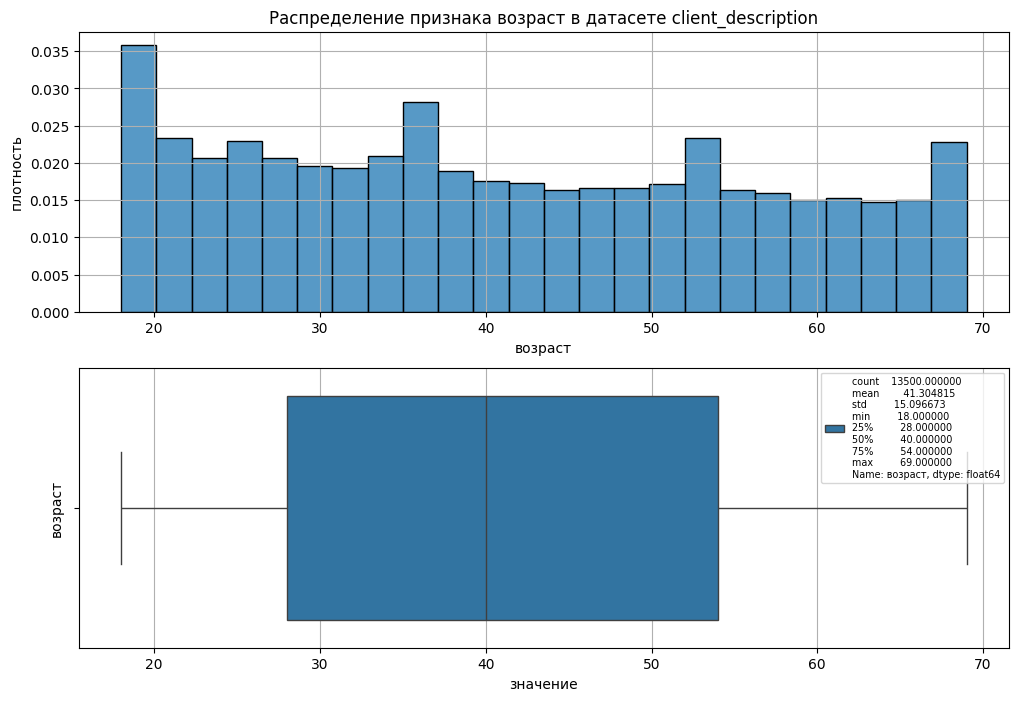

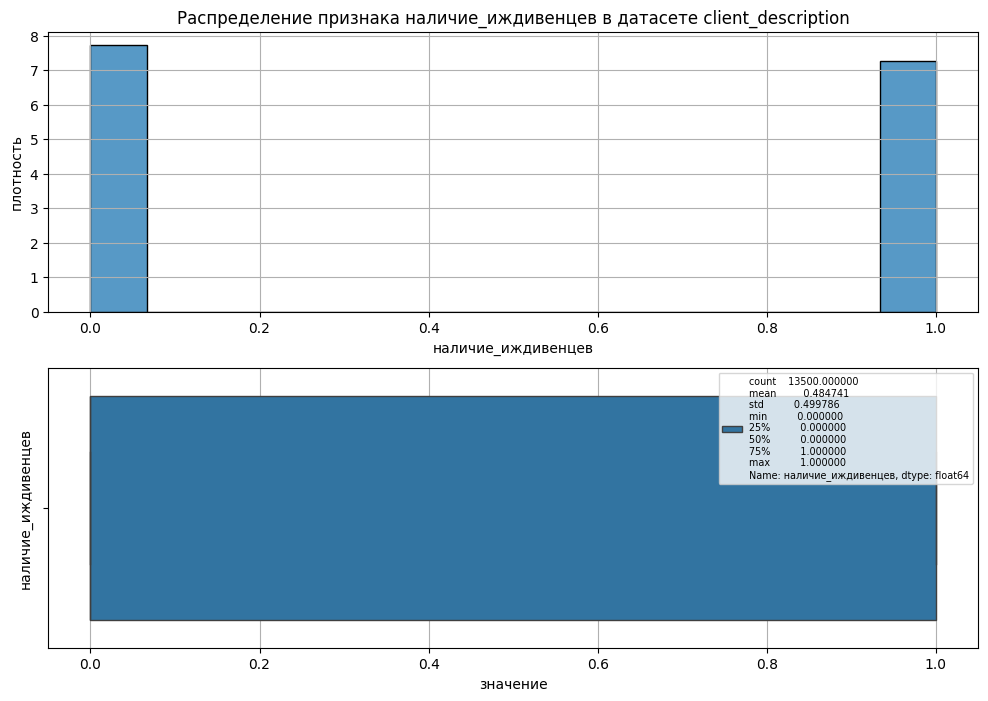

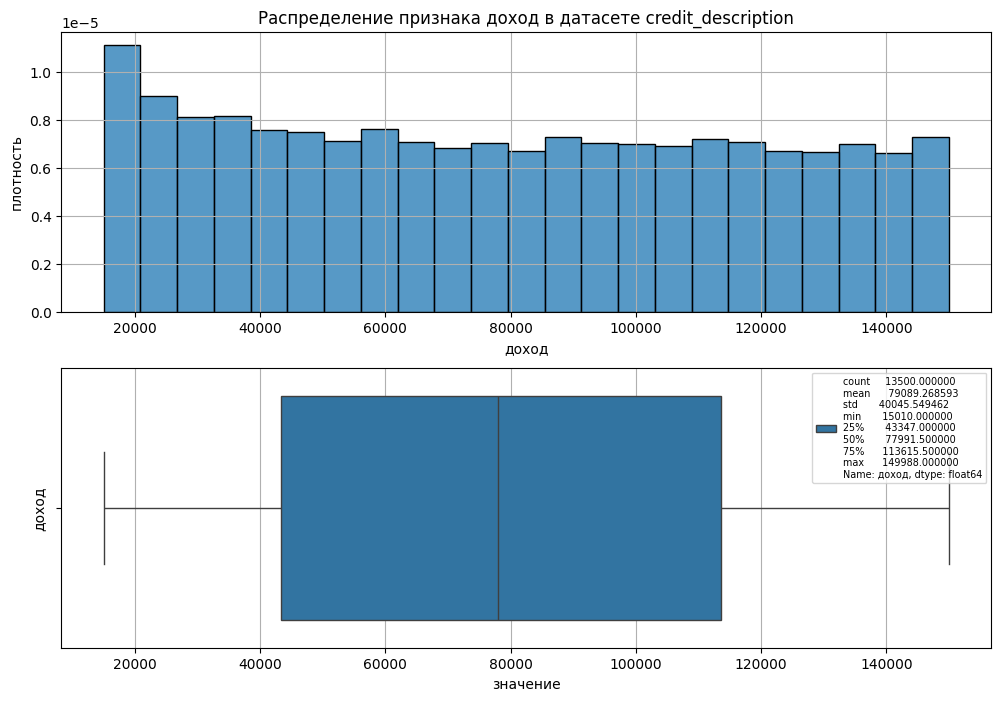

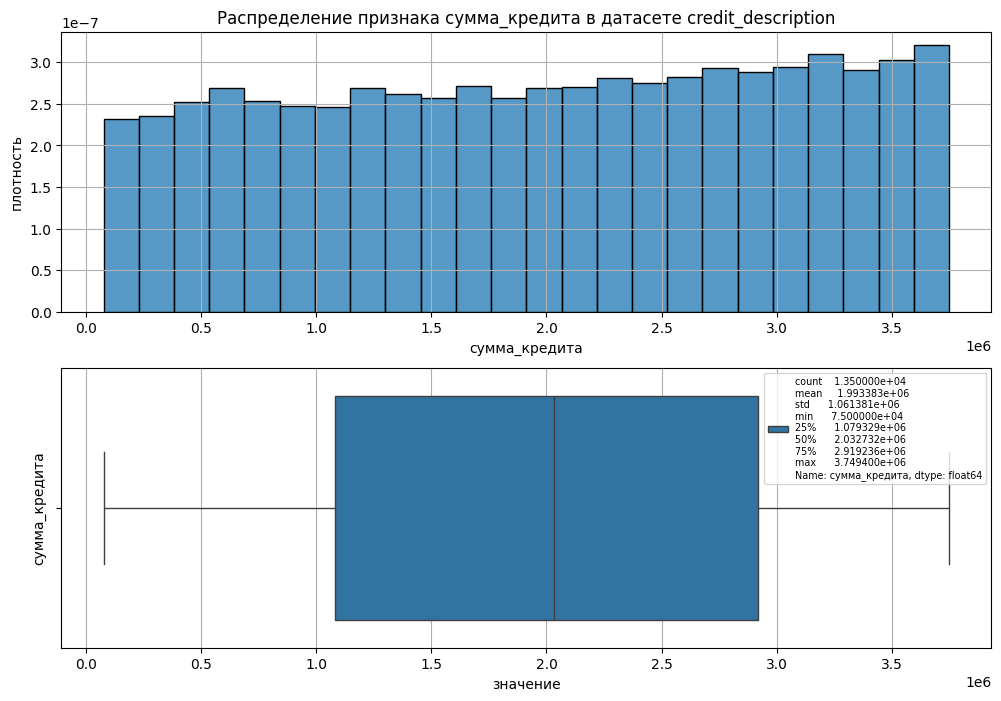

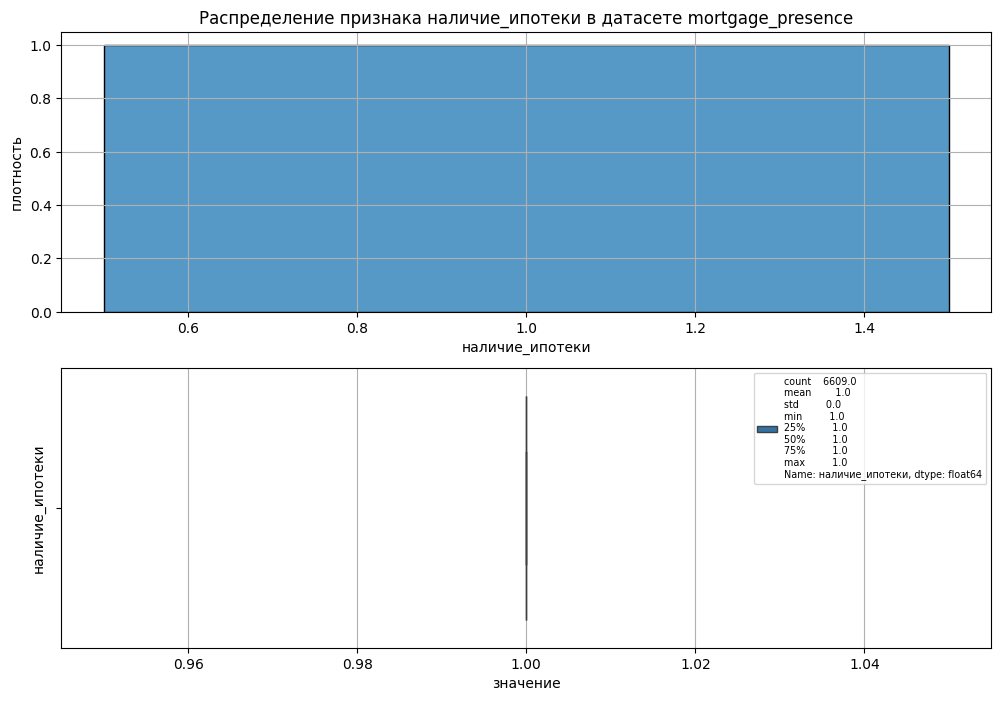

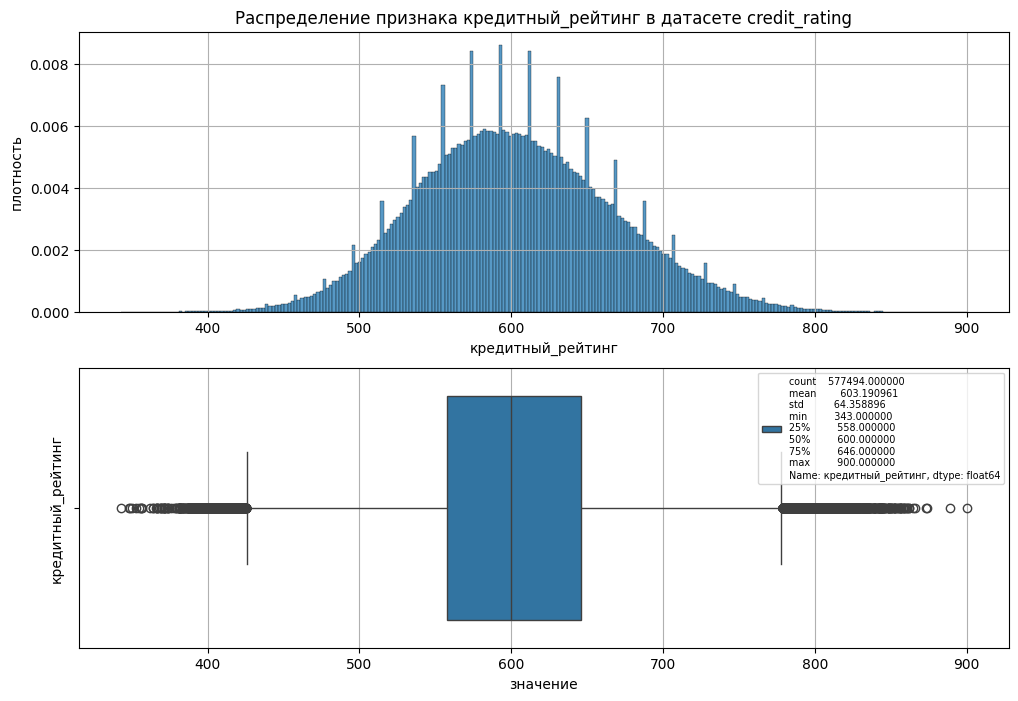

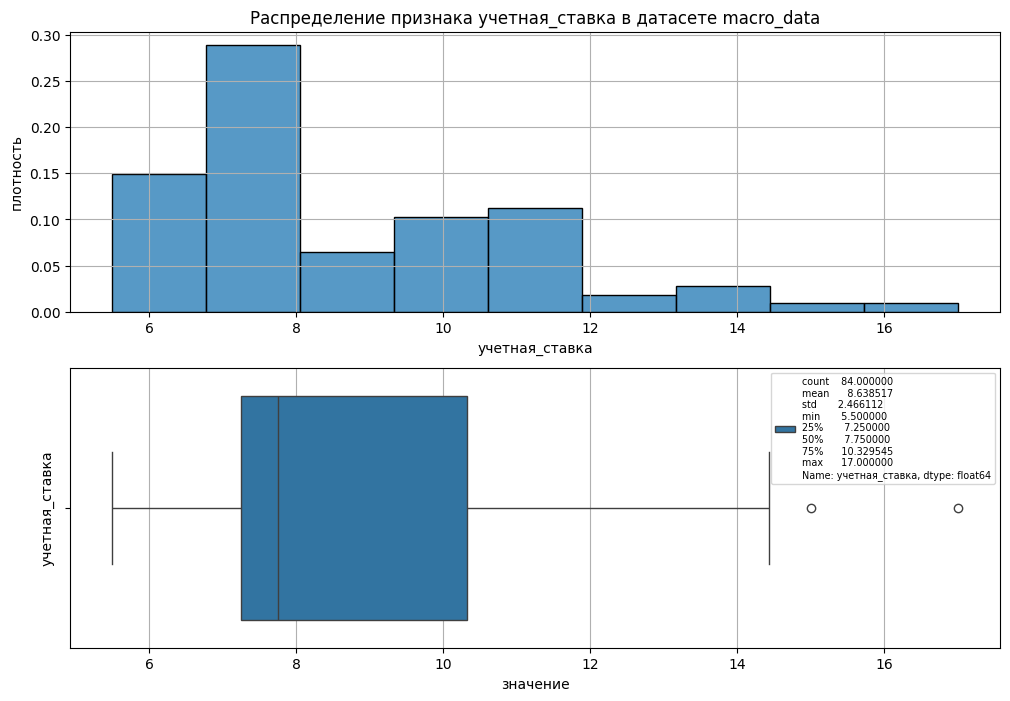

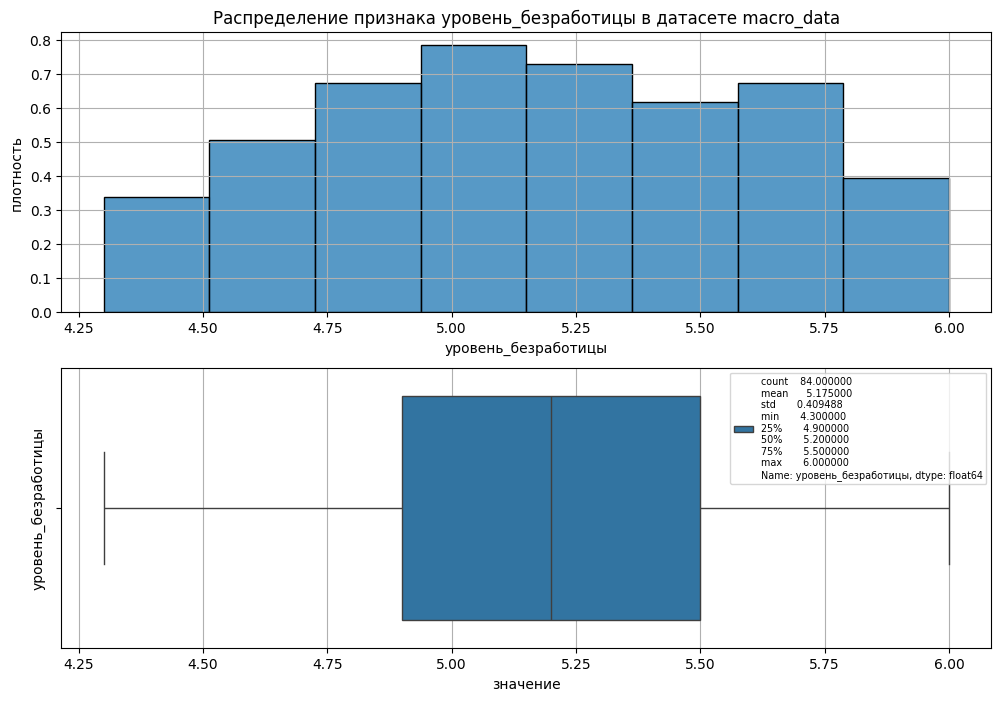

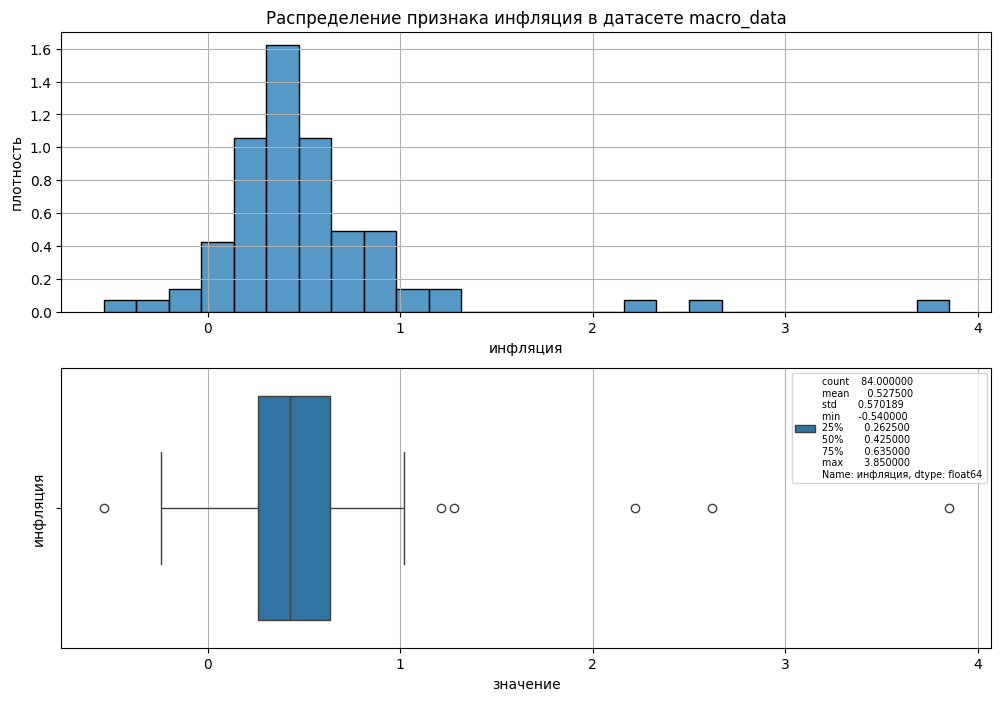

In [13]:
for df, df_name in zip(df_list, df_names):
    _, num_col_names = get_cat_num_cols(df)
    for name in num_col_names:
        plot_hist_box(df=df, feature_name=name, df_name=df_name)

Анализ:
- значение дней просрочек равномерно распределено по диапазону
- траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- возрастные группы представлены равномерно 
- наличие иждевенцев представлено в примерно равных долях 
- по доходу распределение равномерное 
- по сумме кредита распределение равномерное
- данные по наличию ипотеки принимают одно значнение: 1
- распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Возможно, это результат округления или стандратные крейтинги для каких-то категорий граждан
- Распределение по учетной ставке несимметричное, присутствуют малочисленные выбросы (высокая ставка -- достаточно редкое явление)
- По безработице распределение симметричное без выбросов
- По инфляции распределение симметричное, есть выбросы на правом краю диапазона значений

#### Категориальные данные

In [14]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str, df_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    df = df.sort_values(by=name) # сортировка по значениям
    sns.countplot(data=df, x=col_name)
    plt.title(f'Распределение признака {col_name} в датасете {df_name}')
    plt.ylabel('количество')
    plt.xticks(rotation=45)
    plt.show()

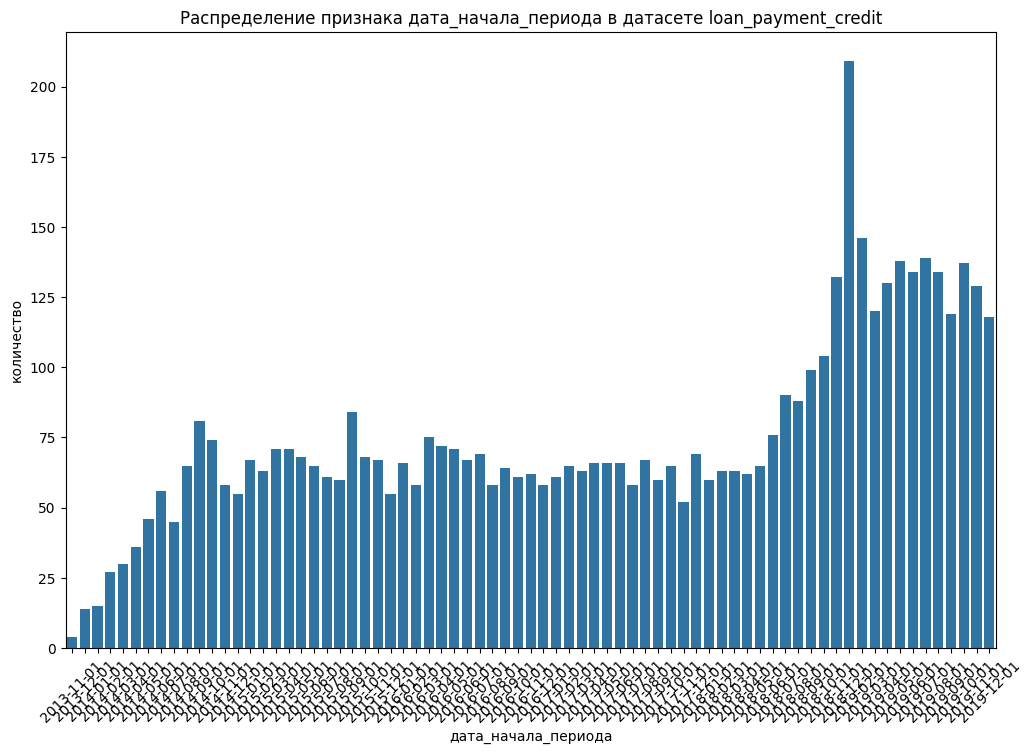

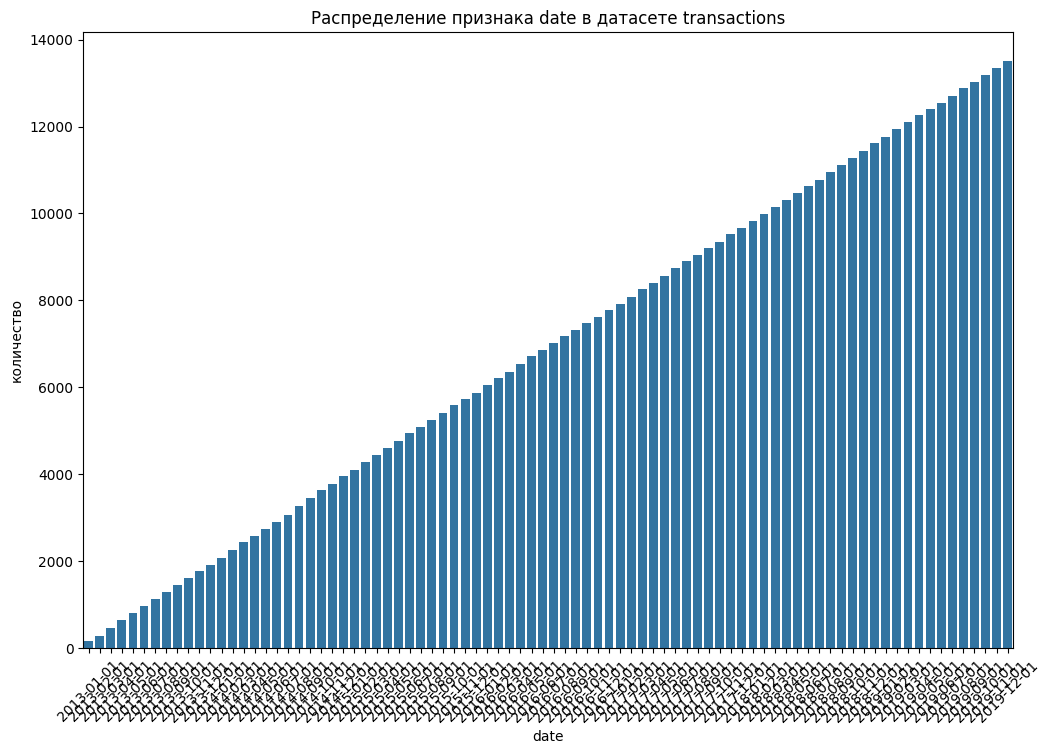

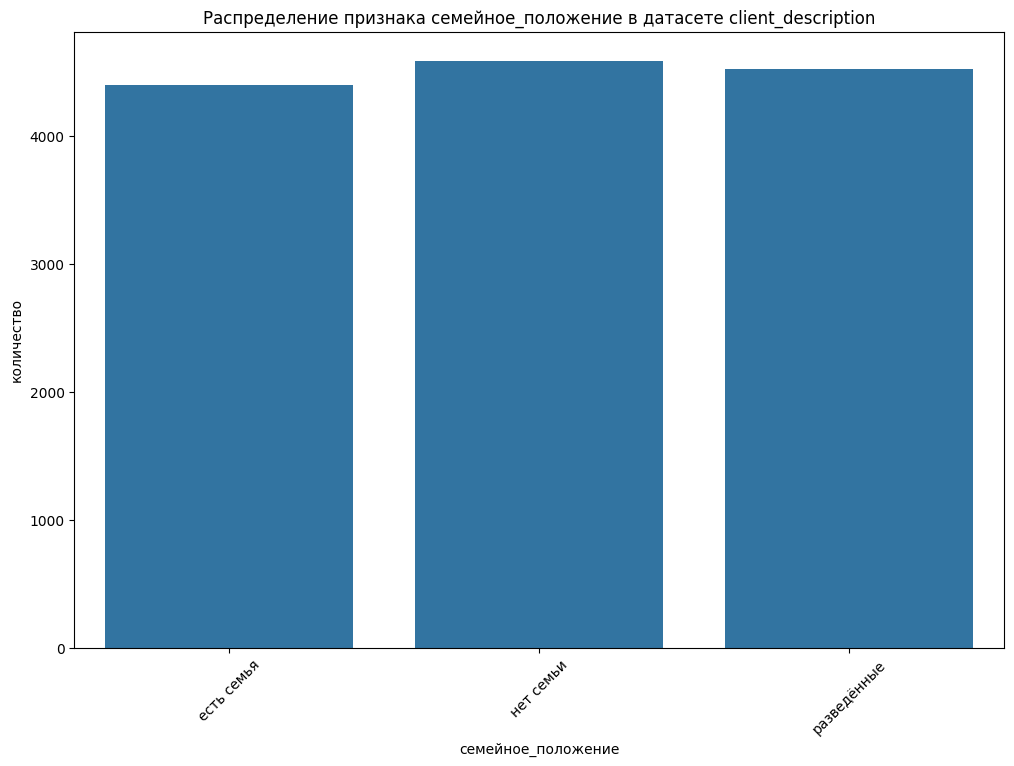

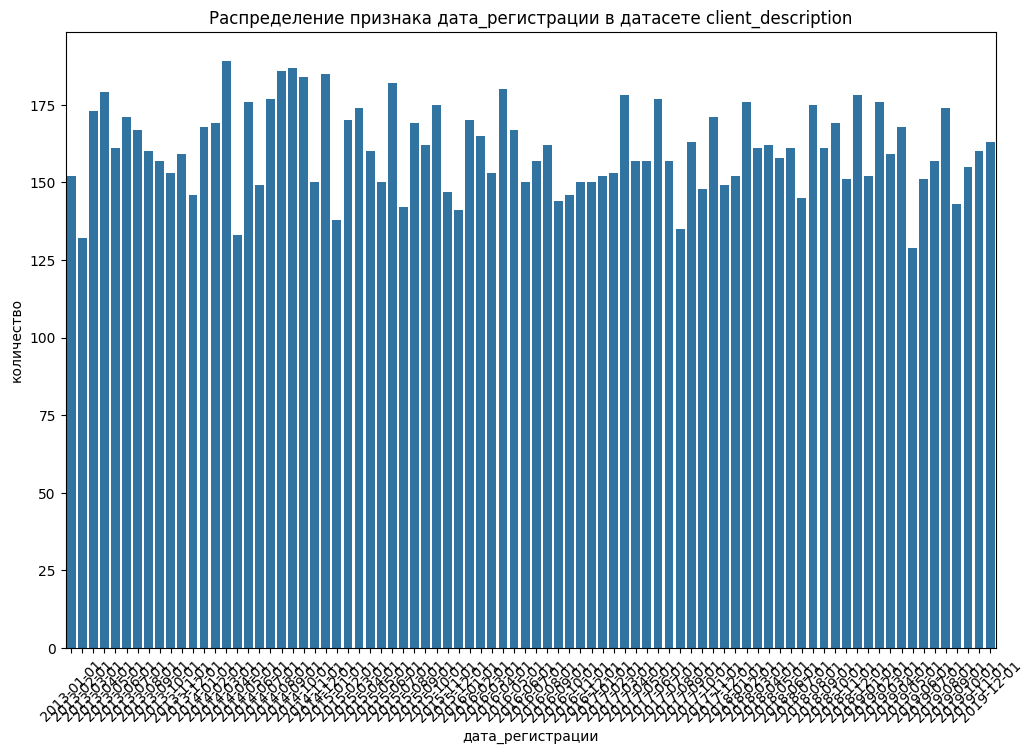

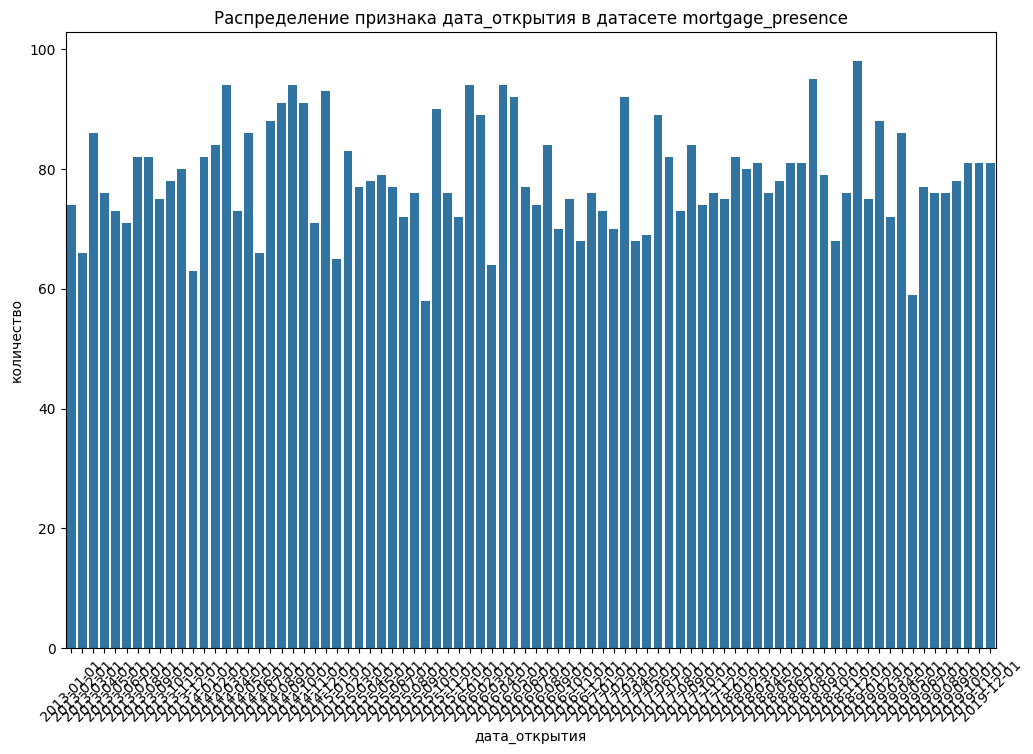

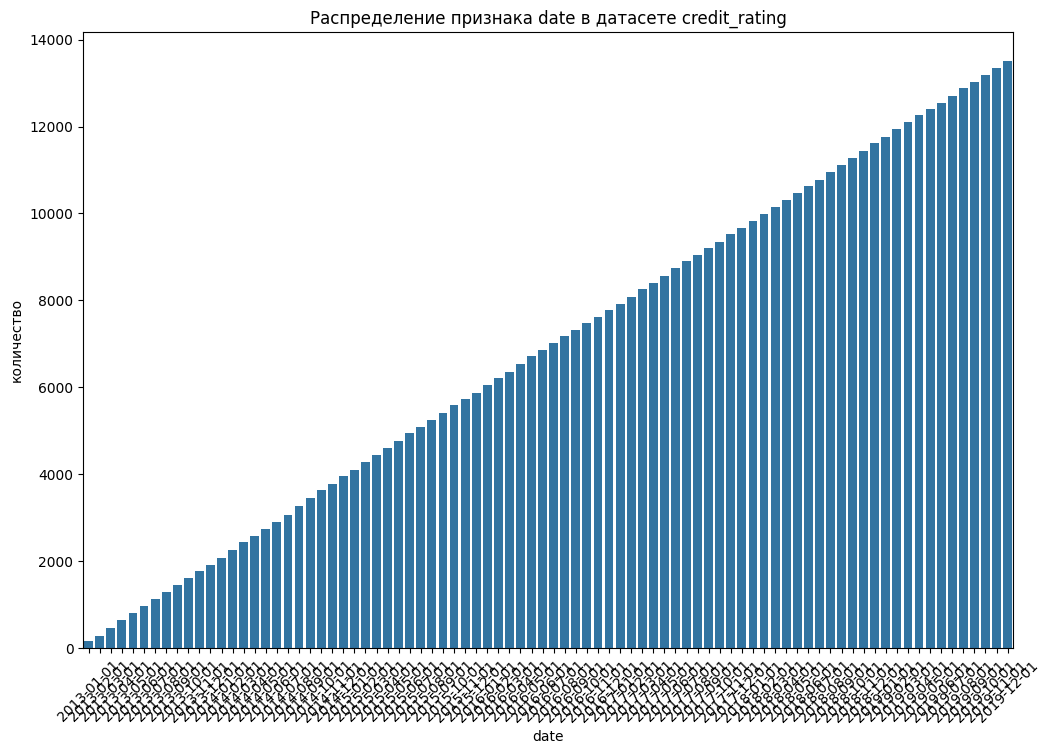

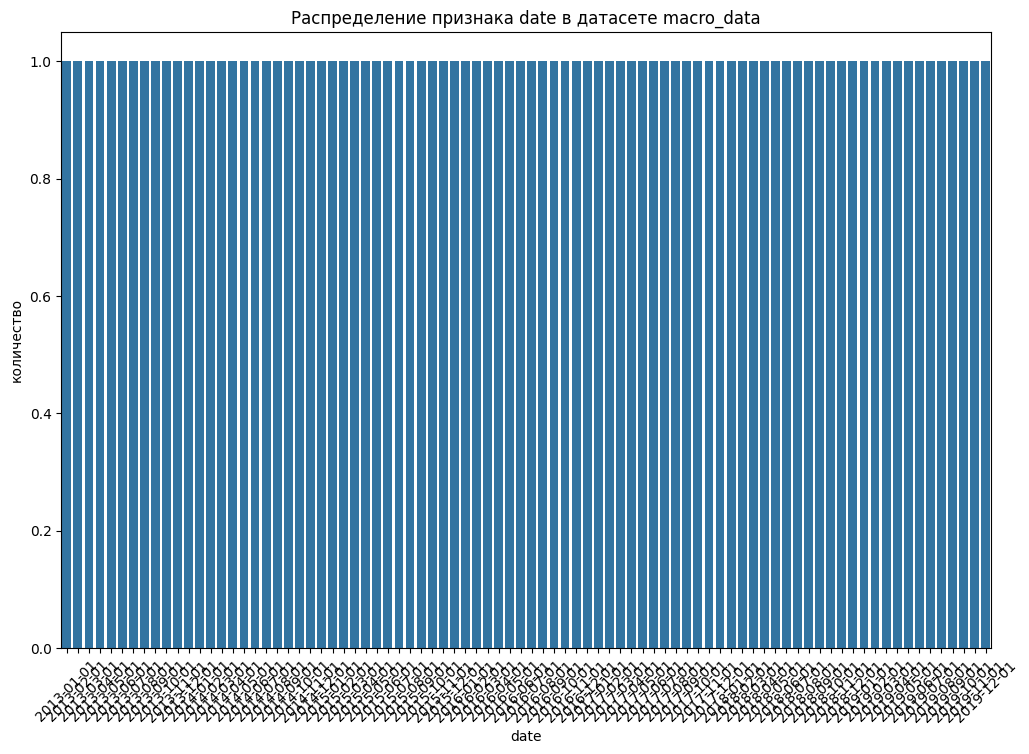

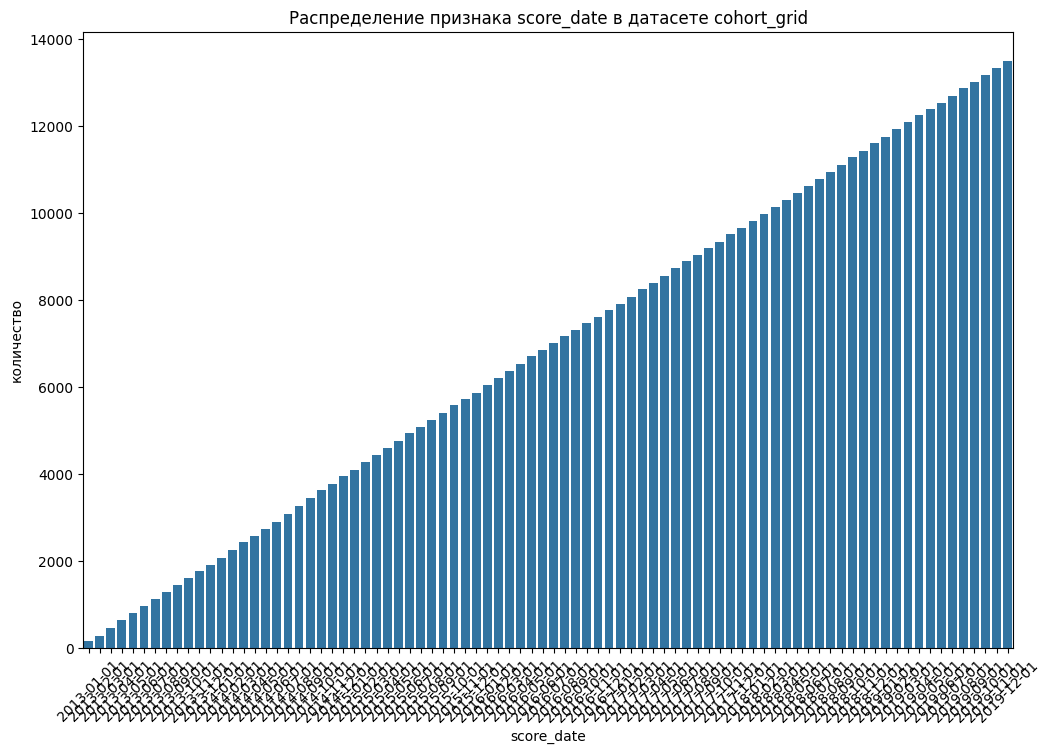

In [15]:
for df, df_name in zip(df_list, df_names):
    cat_col_names, _ = get_cat_num_cols(df)
    cat_col_names = [name for name in cat_col_names if name not in ['ID']]
    for name in cat_col_names:
        plot_count_bars(df=df, col_name=name, df_name=df_name)

Анализ:
- неявных пропусков в виде флагов невалидности нет
- дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- Количество записей о датах транзакций растет линейно 
- по признаку семейного пложения дисбаланса нет 
- даты регистраций распределены равномерно 
- по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- количество дат датасете по кредитным рейтингам растет линейно 
- даты записей макроэкономических показателей равномерно распрелены - по одной записи на дату
- количество дат скоринга растет линейно

### Вывод по ИАД

#### Общие сведения

Данные представлены в виде 8 таблиц:
- Данные о просрочке платежа: loan_payment_credit
- Месячные транзакции клиента: transactions
- Описание клиента на момент регистрации в банке: client_description
- Описание кредита: credit_description
- Данные о наличии ипотеки: mortgage_presence
- Данные о кредитном рейтинге клиента: credit_rating
- Данные о макроэкономических показателях России: macro_data
- Данные о дате проведения поведенческого скоринга: cohort_grid

Типы данных соотвествуют описанию. 

#### Пропуски, дубли

- явных и неявных пропусков/дублей в данных не обнаружено


#### Анализ распределений

Количественные данные:
- loan_payment_credit: значение дней просрочек равномерно распределено по диапазону
- transactions: траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- client_description: по возрасту распределение равномерное
- client_description: наличие иждевенцев представлено в примерно равных долях 
- credit_description: по доходу и сумме кредита распределение равномерное 
- mortgage_presence: данные по наличию ипотеки принимают одно значнение - 1
- credit_rating: распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Выдвинуто предположение, что в происходило округление или имеются стандратные рейтинги для каких-то категорий граждан.
- macro_data: Распределение по учетной ставке несимметричное и имеет малый набор уникальных значений
- macro_data: По безработице распределение симметричное без выбросов
- macro_data: По инфляции распределение симметричное, есть выбросы 

Категориальные данные:
- loan_payment_credit: дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- transactions: Количество записей о датах транзакций растет линейно 
- client_description: по признаку семейного пложения дисбаланса нет 
- credit_rating: даты регистраций распределены равномерно 
- mortgage_presence: по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- credit_rating: количество дат в датасете по кредитным рейтингам растет линейно 
- macro_data: даты записей макроэкономических показателей равномерно распределены - по одной записи на дату
- cohort_grid: количество дат скоринга растет линейно



---
## 3. Формирование датасета

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

In [16]:
cohort_grid = df_list[7].copy()
cohort_grid['score_date'] = pd.to_datetime(cohort_grid['score_date'])
loan_payment_credit = df_list[0].rename(columns={'дата_начала_периода': 'начало_периода_просрочки'})
loan_payment_credit['начало_периода_просрочки'] = pd.to_datetime(loan_payment_credit['начало_периода_просрочки'])

In [17]:
def create_target(loan_payment_credit, cohort_grid):
    """Создать таргет дефолта в течение следующих 365 дней."""
    # Первый эпизод просрочки продолжительностью не менее 90 дней.
    first_default = (
        loan_payment_credit.loc[loan_payment_credit['просрочка_дней'].ge(90)]
        .groupby('ID', as_index=False)['начало_периода_просрочки']
        .min()
        .rename(columns={'начало_периода_просрочки': 'first_default_date'})
    )
    df_result = cohort_grid.merge(
        first_default,
        on='ID',
        how='left',
        validate='many_to_one',
    )

    observation_end = loan_payment_credit[
        'начало_периода_просрочки'
    ].max()
    forecast_horizon = df_result['score_date'] + pd.Timedelta(days=365)

    # Оставляем наблюдения с полностью известным горизонтом таргета.
    df_result = df_result[
        forecast_horizon.le(observation_end)
    ].copy()
    forecast_horizon = forecast_horizon.loc[df_result.index]

    # Интервал таргета: [score_date, score_date + 365 дней).
    df_result['target'] = (
        df_result['first_default_date'].ge(df_result['score_date'])
        & df_result['first_default_date'].lt(forecast_horizon)
    ).astype('int8')

    # Исключаем наблюдения после уже произошедшего первого дефолта.
    df_result = df_result[
        df_result['first_default_date'].isna()
        | df_result['first_default_date'].ge(df_result['score_date'])
    ].copy()

    df_result = df_result.drop(columns='first_default_date')

    return df_result

In [18]:
df_result = create_target(loan_payment_credit, cohort_grid)
df_result

,ID,score_date,target
0,IDF55109846,2013-05-01,0
1,IDF55109846,2013-06-01,0
2,IDF55109846,2013-07-01,0
3,IDF55109846,2013-08-01,0
4,IDF55109846,2013-09-01,0
...,...,...,...
577432,IDF54902735,2014-12-01,1
577433,IDF54902735,2015-01-01,1
577434,IDF54902735,2015-02-01,1
577435,IDF54902735,2015-03-01,1


### Создание итоговой таблицы

In [19]:
transactions = df_list[1].copy()
transactions['date'] = pd.to_datetime(transactions['date'])
transactions = transactions.rename(columns={'date': 'date_transactions'})

In [20]:
# столбцы транзакции для агрегации по прошедшим месяцам
mcc_cols = [
    'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
    'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое'
]

transactions = (
    transactions
    .sort_values(['ID', 'date_transactions'])
    .reset_index(drop=True)
)

In [21]:
# проверка, что пары уникальны
transactions.duplicated(['ID', 'date_transactions']).any()

np.False_

In [22]:
# Исключаем текущий месяц: используем только значения до score_date
past_transactions = transactions.groupby('ID')[mcc_cols].shift(1)

features = transactions[['ID', 'date_transactions']].copy()

for window in [3, 6]: # агрегация за периоды
    rolling_sum = (
        past_transactions
        .groupby(transactions['ID'])
        .rolling(window=window, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
        .sort_index()
    )

    rolling_sum.columns = [
        f'{column}_sum_{window}m' for column in mcc_cols
    ]

    features = features.join(rolling_sum)

features = features.rename(columns={'date_transactions': 'score_date'})

In [23]:
rows_before = len(df_result)

df_result = df_result.merge(
    features,
    on=['ID', 'score_date'],
    how='left',
    validate='one_to_one'
)



In [24]:
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,MCC_5812_sum_6m,MCC_5411_sum_6m,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
2,IDF55109846,2013-07-01,0,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,6979.96,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,6979.96
3,IDF55109846,2013-08-01,0,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,10447.02,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,10447.02
4,IDF55109846,2013-09-01,0,10133.10,11251.72,4059.35,16800.12,3222.49,6495.42,10406.90,10144.11,13400.69,12533.83,5517.31,22511.22,3869.92,8870.20,14466.76,13801.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF54902735,2014-12-01,1,122896.80,21981.84,72696.15,144502.50,12132.94,41293.48,32364.61,72542.98,178078.09,86397.48,100165.29,248093.40,24175.76,77782.66,65751.50,145715.22
334692,IDF54902735,2015-01-01,1,151874.80,24585.68,69911.73,142578.60,13646.00,47216.18,35184.47,71440.34,208997.55,68559.02,109235.07,262452.55,23503.50,83544.71,62782.94,149863.06
334693,IDF54902735,2015-02-01,1,133666.48,25171.55,50051.66,128009.83,13273.83,61052.11,35050.78,71661.79,222737.93,56125.73,112092.25,271298.85,24313.46,99909.70,65759.05,150903.71
334694,IDF54902735,2015-03-01,1,111947.81,29694.57,38500.90,141390.71,15198.05,87636.42,38922.82,80982.33,234844.61,51676.41,111197.05,285893.21,27330.99,128929.90,71287.43,153525.31


In [25]:
client_description = df_list[2].copy()
client_description['дата_регистрации'] = pd.to_datetime(client_description['дата_регистрации'])
client_description

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01
...,...,...,...,...,...
13495,IDF55146629,23,нет семьи,1,2013-05-01
13496,IDF54957110,22,разведённые,1,2017-04-01
13497,IDF54917881,39,нет семьи,0,2014-12-01
13498,IDF54902735,27,разведённые,0,2014-03-01


In [26]:
# ближайшая запись в прошлом с информацией о клиенте
df_result = pd.merge_asof(
    df_result.sort_values('score_date'),
    client_description.sort_values('дата_регистрации'),
    by='ID',
    left_on='score_date',
    right_on='дата_регистрации',
    direction='backward',
    allow_exact_matches=False,
)
df_result = df_result.drop(columns='дата_регистрации')

In [27]:
credit_description = df_list[3].copy()
credit_description

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870
...,...,...,...
13495,IDF55146629,36556,2717295
13496,IDF54957110,52944,3168705
13497,IDF54917881,24748,3663045
13498,IDF54902735,133821,389610


In [28]:
df_result = df_result.merge(credit_description, on='ID', how='left', validate='many_to_one')

In [29]:
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,MCC_5411_sum_6m,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита
0,IDF55059710,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69734,3676065
1,IDF55103453,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49358,573315
2,IDF54965892,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110040,3646260
3,IDF55024298,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51240,1818525
4,IDF55053634,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122376,3649305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF55110368,2018-12-01,0,3876.76,792.32,1548.62,3768.41,421.27,2060.86,1093.12,...,8599.55,795.43,3306.33,2055.08,4674.30,43.0,нет семьи,0.0,31309,2930295
334692,IDF54975599,2018-12-01,0,1511.52,1394.61,932.04,3390.73,284.44,1008.93,764.06,...,7290.81,1017.55,2437.56,3303.84,4318.55,33.0,нет семьи,0.0,27402,1610190
334693,IDF55000010,2018-12-01,0,15922.63,3053.01,5919.51,14883.77,1605.82,8236.89,4192.68,...,37771.09,3509.89,14645.57,8943.31,20515.82,34.0,разведённые,1.0,137048,2176155
334694,IDF54968381,2018-12-01,0,6618.92,8979.98,2844.06,12023.77,2109.84,4351.43,6377.51,...,82665.04,11047.10,55825.93,36269.08,55878.73,24.0,есть семья,0.0,137575,2499345


In [30]:
mortgage_presence = df_list[4].copy()
mortgage_presence

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1
...,...,...,...
6604,IDF55151532,2019-05-01,1
6605,IDF55151572,2017-03-01,1
6606,IDF55151575,2014-02-01,1
6607,IDF55151597,2019-01-01,1


In [31]:
df_result = df_result.merge(mortgage_presence, on='ID', how='left', validate='many_to_one')
df_result['наличие_ипотеки'] = (
    df_result['дата_открытия'].notna()
    & df_result['дата_открытия'].lt(df_result['score_date'])
).astype('int8')
df_result = df_result.drop(columns='дата_открытия')
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки
0,IDF55059710,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69734,3676065,0
1,IDF55103453,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49358,573315,0
2,IDF54965892,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110040,3646260,0
3,IDF55024298,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51240,1818525,0
4,IDF55053634,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122376,3649305,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF55110368,2018-12-01,0,3876.76,792.32,1548.62,3768.41,421.27,2060.86,1093.12,...,795.43,3306.33,2055.08,4674.30,43.0,нет семьи,0.0,31309,2930295,0
334692,IDF54975599,2018-12-01,0,1511.52,1394.61,932.04,3390.73,284.44,1008.93,764.06,...,1017.55,2437.56,3303.84,4318.55,33.0,нет семьи,0.0,27402,1610190,0
334693,IDF55000010,2018-12-01,0,15922.63,3053.01,5919.51,14883.77,1605.82,8236.89,4192.68,...,3509.89,14645.57,8943.31,20515.82,34.0,разведённые,1.0,137048,2176155,0
334694,IDF54968381,2018-12-01,0,6618.92,8979.98,2844.06,12023.77,2109.84,4351.43,6377.51,...,11047.10,55825.93,36269.08,55878.73,24.0,есть семья,0.0,137575,2499345,0


In [32]:
credit_rating = df_list[5].copy()
credit_rating = credit_rating.rename(columns={'date': 'date_credit_rating'})
credit_rating['date_credit_rating'] = pd.to_datetime(
    credit_rating['date_credit_rating']
)
credit_rating

,ID,date_credit_rating,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688
...,...,...,...
577489,IDF54902735,2019-09-01,592
577490,IDF54902735,2019-10-01,592
577491,IDF54902735,2019-11-01,582
577492,IDF54902735,2019-12-01,586


In [33]:
# ближейший кредитный рейтинг в прошлом для заданной даты
df_result = pd.merge_asof(
    df_result.sort_values('score_date'),
    credit_rating.sort_values('date_credit_rating'),
    by='ID',
    left_on='score_date',
    right_on='date_credit_rating',
    direction='backward',
    allow_exact_matches=False,
)
df_result = df_result.drop(columns='date_credit_rating')

In [34]:
# макро экономические показатели за предыдущий известный месяц
macro_data = df_list[6].copy()
macro_data = macro_data.rename(columns={'date': 'macro_date'})
macro_data['macro_date'] = pd.to_datetime(macro_data['macro_date'])

df_result = pd.merge_asof(
    df_result.sort_values('score_date'),
    macro_data.sort_values('macro_date'),
    left_on='score_date',
    right_on='macro_date',
    direction='backward',
    allow_exact_matches=False
)
df_result = df_result.drop(columns='macro_date')


In [35]:
df_result.columns

Index(['ID', 'score_date', 'target', 'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
       'MCC_5812_sum_3m', 'MCC_5411_sum_3m', 'MCC_3990_sum_3m',
       'MCC_5722_sum_3m', 'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
       'MCC_5300_sum_6m', 'MCC_5814_sum_6m', 'MCC_5812_sum_6m',
       'MCC_5411_sum_6m', 'MCC_3990_sum_6m', 'MCC_5722_sum_6m',
       'MCC_4900_sum_6m', 'MCC_другое_sum_6m', 'возраст', 'семейное_положение',
       'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки',
       'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы',
       'инфляция'],
      dtype='object')

### Создание новых признаков

1. Признак:
- **income_diff = доход_за_3_месяца  / суммарные_траты_по_всем_категориям_за_3_месяца**

Предположение:
- если в течение какого-то срока траты клиента превосходят его доход, то в будущем возрастает вероятность неплатежа по задолженности 

In [36]:
# отношение суммарного дохода к тратам за 3 месяца
mcc_3m_cols = [
    'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
    'MCC_5812_sum_3m', 'MCC_5411_sum_3m',
    'MCC_3990_sum_3m', 'MCC_5722_sum_3m',
    'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
]

spend_3m = df_result[mcc_3m_cols].sum(axis=1, min_count=1)

df_result['income_spend_ratio_3m'] = (
    3 * df_result['доход'] / spend_3m.replace(0, np.nan)
)

In [37]:
df_result.columns

Index(['ID', 'score_date', 'target', 'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
       'MCC_5812_sum_3m', 'MCC_5411_sum_3m', 'MCC_3990_sum_3m',
       'MCC_5722_sum_3m', 'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
       'MCC_5300_sum_6m', 'MCC_5814_sum_6m', 'MCC_5812_sum_6m',
       'MCC_5411_sum_6m', 'MCC_3990_sum_6m', 'MCC_5722_sum_6m',
       'MCC_4900_sum_6m', 'MCC_другое_sum_6m', 'возраст', 'семейное_положение',
       'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки',
       'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы',
       'инфляция', 'income_spend_ratio_3m'],
      dtype='object')

2. Признаки динамики кредитного рейтинга:
- **rating_mean_6m** -- средний рейтинг за 6 месяцев;
- **rating_std_6m** -- волатильность рейтинга за 6 месяцев.

Предположение:
- снижение рейтинга и высокая волатильность могут сигнализировать об ухудшении платёжного поведения клиента.

In [38]:
rating_history = df_result[
    ['ID', 'score_date', 'кредитный_рейтинг']
].sort_values(['ID', 'score_date'])

rating_by_client = rating_history.groupby('ID')['кредитный_рейтинг']

rating_history['rating_mean_6m'] = (
    rating_by_client
    .rolling(window=6, min_periods=2)
    .mean()
    .reset_index(level=0, drop=True)
)
rating_history['rating_std_6m'] = (
    rating_by_client
    .rolling(window=6, min_periods=2)
    .std()
    .reset_index(level=0, drop=True)
)

rating_feature_cols = [
    'rating_mean_6m',
    'rating_std_6m',
]
df_result[rating_feature_cols] = rating_history[rating_feature_cols]

df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
0,IDF55059710,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69734,3676065,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF54917442,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,54987,3408210,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDF55103453,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,49358,573315,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDF54965892,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,110040,3646260,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDF55024298,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,51240,1818525,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF54991388,2018-12-01,1,36564.99,51479.30,15137.49,64892.30,10909.40,24692.94,29017.99,...,76977,1572630,0,618.0,7.5,4.8,0.5,0.838425,624.600000,14.909728
334692,IDF54961586,2018-12-01,0,7762.07,3978.13,3298.41,14304.88,1908.56,7579.89,7836.09,...,112922,552195,0,603.0,7.5,4.8,0.5,6.144417,604.333333,7.685484
334693,IDF55110368,2018-12-01,0,3876.76,792.32,1548.62,3768.41,421.27,2060.86,1093.12,...,31309,2930295,0,607.0,7.5,4.8,0.5,5.981632,610.333333,7.366591
334694,IDF55000010,2018-12-01,0,15922.63,3053.01,5919.51,14883.77,1605.82,8236.89,4192.68,...,137048,2176155,0,513.0,7.5,4.8,0.5,6.605818,517.833333,4.915960


### Анализ итоговой таблицы

Проверка целевой переменой

In [39]:
df_result['target'].sum() / len(df_result['target']) * 100

np.float64(13.255013504792409)

Анализ:
- наблюдается дисбаланс классов в целевой переменной

Рекомендация:
- необходимо воспользоваться оверсэмплингом/андерсэмплингом в пайплайне предобработки данных для улучшения качества предсказания

In [40]:
# контроль отсутствия дублей
df_result.duplicated(['ID', 'score_date']).any()

np.False_

In [41]:
# колонки с пропусками 
len(df_result.columns[df_result.isna().any()].to_list())

26

#### Промежуточный итог по созданию общей таблицы

- таблица состоит из 29 столбцов-признаков, характеризующих клиентов и макроэкономическую ситуацию в стране 
- кроме того, таблица содержит: target - целевая переменная, score_date - дата оценки, ID - идентификатор пользователя
- в рамках целевой переменной есть дисбаланс. В пайплайн обучения необходимо встроить методы балансировки 
- большинство временных рядов содержат пропуски. Их необходимо обработать 

---
## 4. Пайплайн предобработки данных

In [42]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     334696 non-null  object        
 1   score_date             334696 non-null  datetime64[ns]
 2   target                 334696 non-null  int8          
 3   MCC_5300_sum_3m        323083 non-null  float64       
 4   MCC_5814_sum_3m        323083 non-null  float64       
 5   MCC_5812_sum_3m        323083 non-null  float64       
 6   MCC_5411_sum_3m        323083 non-null  float64       
 7   MCC_3990_sum_3m        323083 non-null  float64       
 8   MCC_5722_sum_3m        323083 non-null  float64       
 9   MCC_4900_sum_3m        323083 non-null  float64       
 10  MCC_другое_sum_3m      323083 non-null  float64       
 11  MCC_5300_sum_6m        323083 non-null  float64       
 12  MCC_5814_sum_6m        323083 non-null  floa

In [43]:
get_cat_num_cols(df=df_result)

(['ID', 'семейное_положение'],
 ['target',
  'MCC_5300_sum_3m',
  'MCC_5814_sum_3m',
  'MCC_5812_sum_3m',
  'MCC_5411_sum_3m',
  'MCC_3990_sum_3m',
  'MCC_5722_sum_3m',
  'MCC_4900_sum_3m',
  'MCC_другое_sum_3m',
  'MCC_5300_sum_6m',
  'MCC_5814_sum_6m',
  'MCC_5812_sum_6m',
  'MCC_5411_sum_6m',
  'MCC_3990_sum_6m',
  'MCC_5722_sum_6m',
  'MCC_4900_sum_6m',
  'MCC_другое_sum_6m',
  'возраст',
  'наличие_иждивенцев',
  'доход',
  'сумма_кредита',
  'наличие_ипотеки',
  'кредитный_рейтинг',
  'учетная_ставка',
  'уровень_безработицы',
  'инфляция',
  'income_spend_ratio_3m',
  'rating_mean_6m',
  'rating_std_6m'])

In [44]:
# сортировка датасета
df_result.sort_values(by=['score_date', 'ID'], inplace=True)

In [45]:
# числовые признаки, которые по смыслу явяются категориальными
NUM_SPECIAL_MOST_FREQ = ['наличие_иждивенцев'] # замена пропусков на наиболее часто встречающееся значение
NUM_SPECIAL_ZERO = ['наличие_ипотеки']  # замена на флаг отсутсвия - 0

In [46]:
# отбор признаков

def select_cat_one_hot(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_num_classic(X):
    num_cols_continues = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    special_num_cats = NUM_SPECIAL_ZERO + NUM_SPECIAL_MOST_FREQ
    return [name for name in num_cols_continues if name not in special_num_cats]

def select_num_special_zero(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_SPECIAL_ZERO]

def select_num_special_mf(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_SPECIAL_MOST_FREQ]

In [47]:
class IQROutliersReplacer(BaseEstimator, TransformerMixin):
    """Фильтрация выбросов по межквартильному размаху с заданным коэффициентом"""
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bound_ = None
        self.upper_bound_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bound_ = q1 - self.factor * iqr
        self.upper_bound_ = q3 + self.factor * iqr
        
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        for col in X.columns:
            X.loc[(X[col] < self.lower_bound_[col]) | (X[col] > self.upper_bound_[col]), col] = np.nan
        return X


In [48]:
def create_preprocessing_pipeline(
        with_outliers_filtering: bool = False
):
    """
    Создание трансформера предобработки данных.

    Args:
        with_outliers_filtering (bool): флаг наличия фильтации выбросов

    Returns:
        ColumnTransformer: Трансформер предобработки данных
    """
    # категориальные признаки

    # малочисленные
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])

    # количественные данные, которые по смыслу являются категориальными
    # замена пропусков на наиболее часто встречающееся значение
    num_special_mf_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler()),
    ])

    # особые признаки: отсутстие значения = 0
    num_special_zero_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', MinMaxScaler()),
    ])

    # количественные признаки с возможными выбросами
    num_classic_steps = []
    if with_outliers_filtering:
        num_classic_steps.append(
            ('outliears', IQROutliersReplacer())
        )
    num_classic_steps += [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ]

    num_classic_pipeline = Pipeline(steps=num_classic_steps)

    transformers = [
        ('cat_one_hot_pipeline', cat_one_hot_pipeline, select_cat_one_hot),
        ('num_special_mf_pipeline', num_special_mf_pipeline, select_num_special_mf),
        ('num_special_zero_pipeline', num_special_zero_pipeline, select_num_special_zero),
        ('num_classic_pipeline', num_classic_pipeline, select_num_classic),
    ]
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    return preprocessor


--- 
## 5. Базовые модели


### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

#### Разбиение выборки на train/test

In [49]:
df_result = df_result.sort_values(['score_date', 'ID']).reset_index(drop=True)

In [50]:
metadata = df_result[['ID', 'score_date']].copy()
months = metadata['score_date'].dt.strftime('%Y-%m')

groups, _ = pd.factorize(months)

X = df_result.drop(columns=['target', 'ID', 'score_date']).set_index(months)
y = pd.Series(df_result['target'], name='target')
display(X.head(), y.head())

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,88630,3174630,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,118478,1484085,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,149716,2326665,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,84077,265020,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70568,3656715,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0    1
1    0
2    0
3    0
4    0
Name: target, dtype: int8

In [107]:
# Разделение по календарным месяцам.

test_months = 12
calib_months = 12

test_start_month = months.unique()[-test_months]
calib_start_month = months.unique()[-test_months-calib_months]

train_mask = months < calib_start_month
calib_mask = (months >= calib_start_month) & (months < test_start_month)
test_mask = months >= test_start_month


In [108]:
X_train = X[train_mask.values]
y_train = y[train_mask.values]
train_groups = groups[train_mask.values]

display(X_train.head(), y_train.head(), train_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,88630,3174630,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,118478,1484085,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,149716,2326665,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,84077,265020,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70568,3656715,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0    1
1    0
2    0
3    0
4    0
Name: target, dtype: int8

array([ 0,  0,  0, ..., 47, 47, 47])

In [109]:
X_calib = X[calib_mask.values]
y_calib = y[calib_mask.values]
calib_groups = groups[calib_mask.values]

display(X_calib.head(), y_calib.head(), calib_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2017-01,9172.12,7700.49,5745.44,18709.82,1815.41,5953.74,4571.31,12067.77,17367.67,17312.63,...,134076,2113275,0,533.0,10.0,5.4,0.4,6.118830,548.000000,10.807405
2017-01,4026.19,708.68,1753.13,3557.25,367.02,1292.79,943.63,1958.09,5606.57,1914.83,...,29635,2474190,0,553.0,10.0,5.4,0.4,6.086557,580.000000,19.718012
2017-01,22177.98,19136.11,9486.82,41882.41,6875.30,15109.58,30318.54,23868.72,22177.98,19136.11,...,56946,96765,0,633.0,10.0,5.4,0.4,1.011741,617.333333,13.796135
2017-01,3073.93,4085.42,1312.09,5301.42,844.72,1994.60,2293.31,3811.10,6198.36,5754.05,...,51990,1792740,0,639.0,10.0,5.4,0.4,6.865907,652.000000,14.886235
2017-01,8074.58,2631.43,3061.91,12696.24,1467.94,7928.89,6323.04,7414.86,23403.74,5226.95,...,110938,1566420,0,577.0,10.0,5.4,0.4,6.710110,601.000000,13.401492


160953    0
160954    0
160955    0
160956    0
160957    0
Name: target, dtype: int8

array([48, 48, 48, ..., 59, 59, 59])

In [110]:
X_test = X[test_mask.values]
y_test = y[test_mask.values]
test_groups =groups[test_mask.values]

display(X_test.head(), y_test.head(), test_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2018-01,40711.43,33750.26,17136.80,70093.37,11456.85,26141.51,52505.77,42173.08,40711.43,33750.26,...,100284,3381045,0,652.0,8.011905,5.2,0.42,1.023414,658.666667,7.637626
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,105732,495195,0,NaN,8.011905,5.2,0.42,NaN,NaN,NaN
2018-01,9490.89,8308.72,5602.14,17951.96,1691.53,5646.75,4342.70,11875.77,16722.96,17472.02,...,134076,2113275,0,550.0,8.011905,5.2,0.42,6.196659,543.666667,6.653320
2018-01,4349.58,746.91,2004.92,4112.65,410.07,1413.16,969.21,2067.97,6144.49,2165.08,...,29635,2474190,0,559.0,8.011905,5.2,0.42,5.530820,559.500000,8.068457
2018-01,4274.17,3460.75,1747.80,7325.80,1162.71,3003.65,5548.38,4595.76,34156.68,9439.30,...,56946,96765,0,552.0,8.011905,5.2,0.42,5.489826,567.000000,21.725561


240401    0
240402    0
240403    0
240404    0
240405    0
Name: target, dtype: int8

array([60, 60, 60, ..., 71, 71, 71])

In [141]:
# --- CV-параметры ---
cv_args = {
    'test_size': 12,
    'train_size': 24,
    'n_splits': 3,
    'shift_size': 3,
    "gap_size": 0,
    'window_type': 'rolling',
}
tscv = GroupTimeSeriesSplit(**cv_args)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/mlxtend/evaluate/time_series.py:335: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


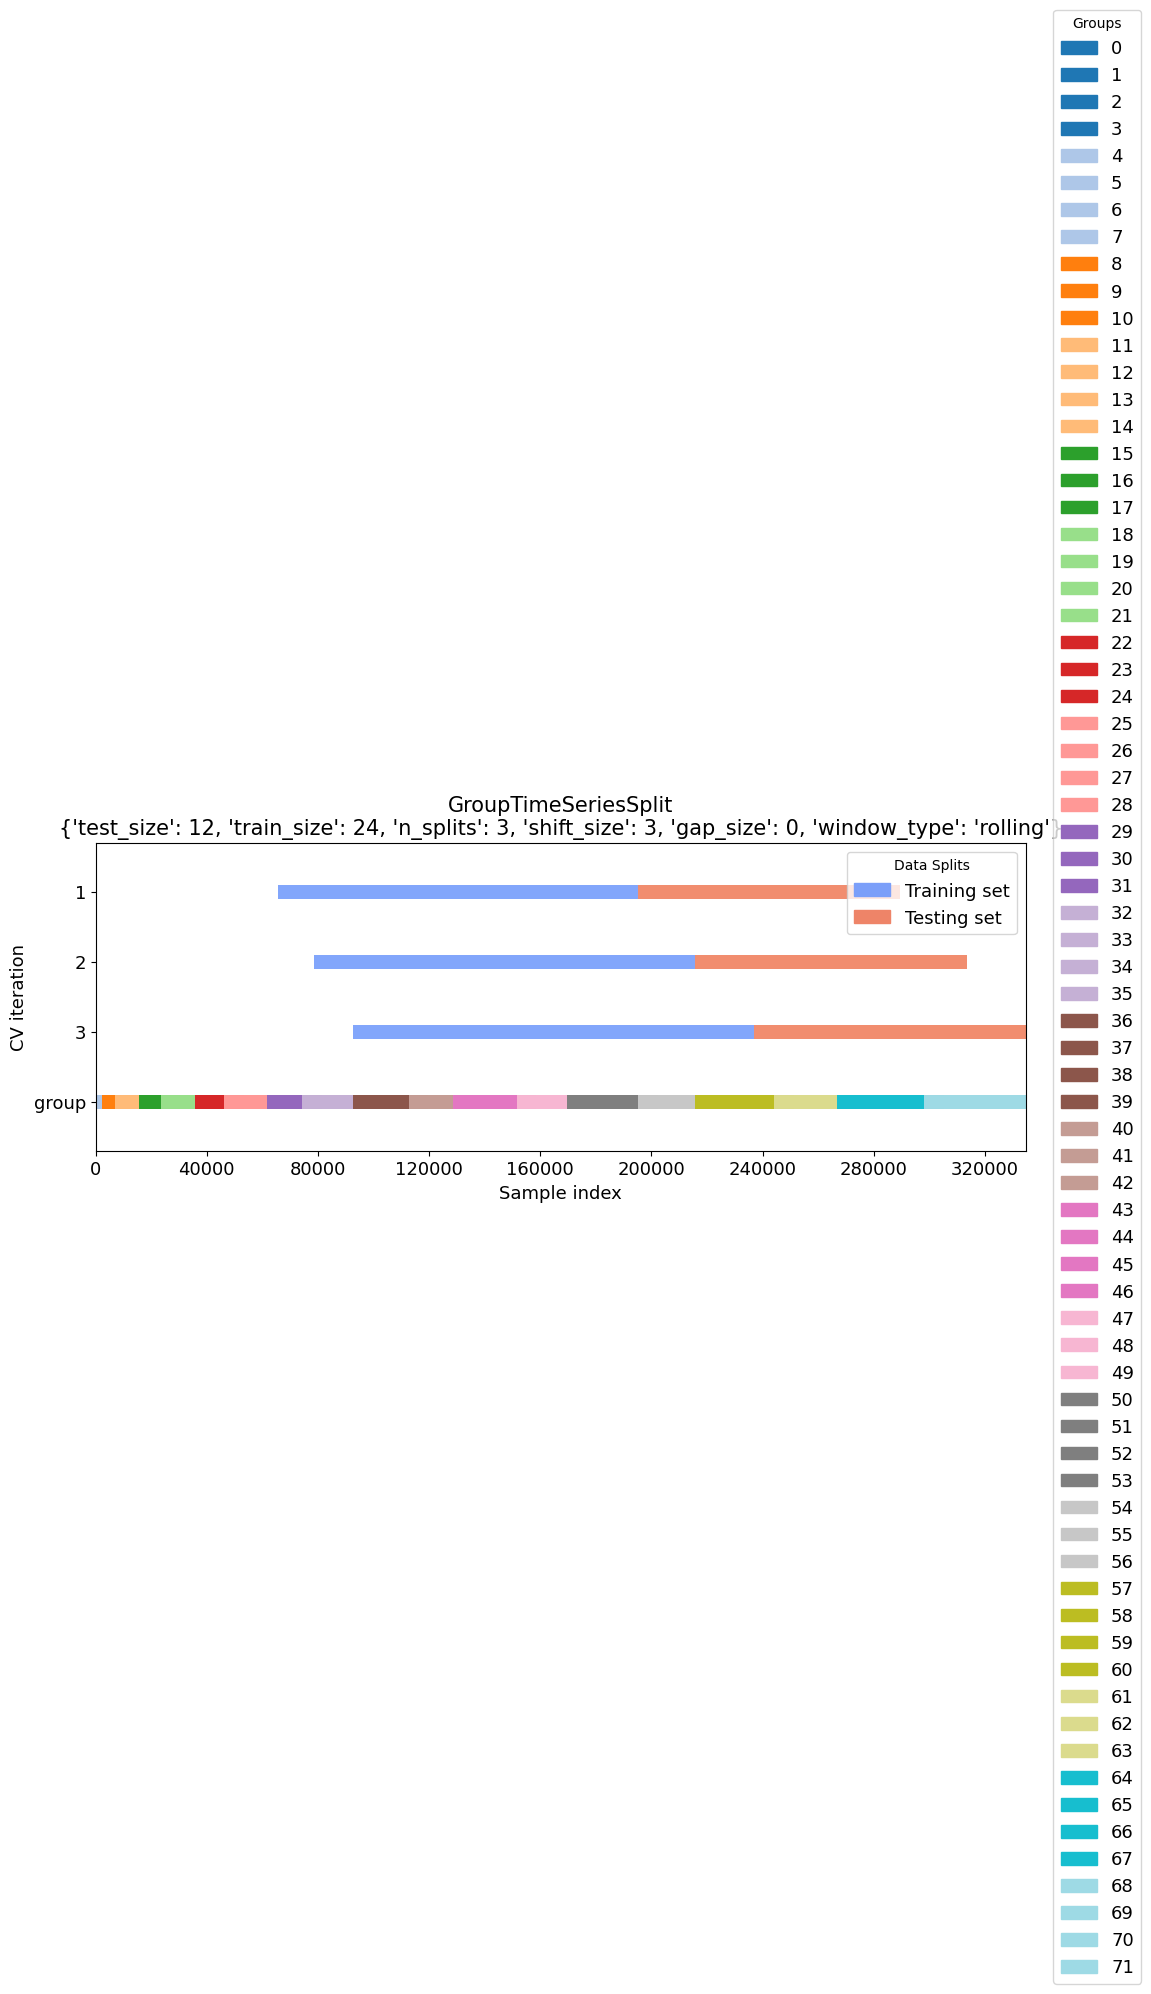

In [142]:
plot_splits(X=X, y=y, groups=groups, **cv_args)

#### Базовые модели для обучения

In [143]:
# логрег
logreg_base_pipeline = Pipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

In [144]:
# случайный лес
random_forest_base_pipeline = Pipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, max_depth=30, n_jobs=-1))
])

#### Обучение кросс валидацией и оценка качества

In [145]:
def calculate_approval_metrics(y_true, y_pred):
    """
    Рассчитывает Approval Rate, Default Rate, Missed Defaults Rate
    для заданного порога.
    
    Args:
        y_true : array-like, истинные метки (1 - дефолт, 0 - ок)
        y_pred : array-like, предсказанные классы (1 - дефолт, 0 - ок)
    
    Returns:
        dict с метриками
    """
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Одобряем клиентов, для которых модель предсказала отсутствие дефолта.
    approved_mask = y_pred == 0
    n_approved = approved_mask.sum()
    n_total = len(y_true)
    
    defaults_among_approved = y_true[approved_mask].sum()
    total_defaults = y_true.sum()
    
    approval_rate = n_approved / n_total
    default_rate = defaults_among_approved / n_approved if n_approved > 0 else 0.0
    missed_defaults_rate = defaults_among_approved / total_defaults if total_defaults > 0 else 0.0
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)

    return {
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
    }

In [146]:
def cross_valid_cycle(
        model,
        tscv,
        X: pd.DataFrame,
        y: pd.Series,
        groups: np.ndarray,
):
    scores_list = []
    split_iterator = tscv.split(X, y, groups=groups)

    for fold, (train_index, valid_index) in enumerate(split_iterator):
        # Разделение данных для текущего фолда.
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)

        y_pred = fold_model.predict(X_valid)

        scores = calculate_approval_metrics(y_true=y_valid, y_pred=y_pred)
        scores['fold'] = fold
        scores['train_start'] = groups[train_index].min()
        scores['train_end'] = groups[train_index].max()
        scores['valid_start'] = groups[valid_index].min()
        scores['valid_end'] = groups[valid_index].max()
        scores_list.append(scores)

    return scores_list

In [147]:
def plot_score_by_folds(
        scores_list: list[dict],
        model_name: str = 'Модель',
):
    """Визуализация метрик по фолдам кросс-валидации."""

    scores_df = pd.DataFrame(scores_list).sort_values('fold')
    metric_names = {
        'approval_rate': 'Approval rate',
        'default_rate': 'Default rate',
        'missed_defaults_rate': 'Missed defaults rate',
    }
    metric_cols = list(metric_names)

    plot_df = scores_df[['fold'] + metric_cols].melt(
        id_vars='fold',
        value_vars=metric_cols,
        var_name='metric',
        value_name='score',
    )
    plot_df['metric'] = plot_df['metric'].map(metric_names)
    plot_df['score_pct'] = plot_df['score'] * 100

    fig, ax = plt.subplots()
    sns.barplot(
        data=plot_df,
        x='fold',
        y='score_pct',
        hue='metric',
        ax=ax,
    )

    ax.set_title(f'Метрики кросс-валидации: {model_name}')
    ax.set_xlabel('Фолд')
    ax.set_ylabel('Значение, %')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax.legend(title='Метрика', loc='upper left', bbox_to_anchor=(1.02, 1))

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

    if {'train_start', 'train_end', 'valid_start', 'valid_end'}.issubset(scores_df.columns):
        fold_labels = [
            f"{row.fold}\ntrain: {row.train_start}-{row.train_end}\nvalid: {row.valid_start}-{row.valid_end}"
            for row in scores_df.itertuples()
        ]
        ax.set_xticks(range(len(fold_labels)))
        ax.set_xticklabels(fold_labels)

    plt.tight_layout()
    plt.show()


def summarize_cv_metrics(
        scores_list: list[dict],
        model_name: str,
) -> pd.DataFrame:
    """Сформировать сводку средних метрик по фолдам кросс-валидации."""

    metric_cols = [
        'approval_rate',
        'default_rate',
        'missed_defaults_rate',
        'accuracy',
        'roc_auc'
    ]
    scores_df = pd.DataFrame(scores_list)

    mean_metrics = scores_df[metric_cols].mean()

    return pd.DataFrame([{
        'model': model_name,
        'n_folds': len(scores_df),
        **mean_metrics.to_dict(),
    }])

In [148]:
def mean_missed_defaults_rate(scores_list):
    scores_df = pd.DataFrame(scores_list)
    return scores_df['missed_defaults_rate'].mean()


Обучение

In [149]:
logreg_base_result = cross_valid_cycle(
    model=logreg_base_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

In [150]:
random_forest_base_result = cross_valid_cycle(
    model=random_forest_base_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

Результаты

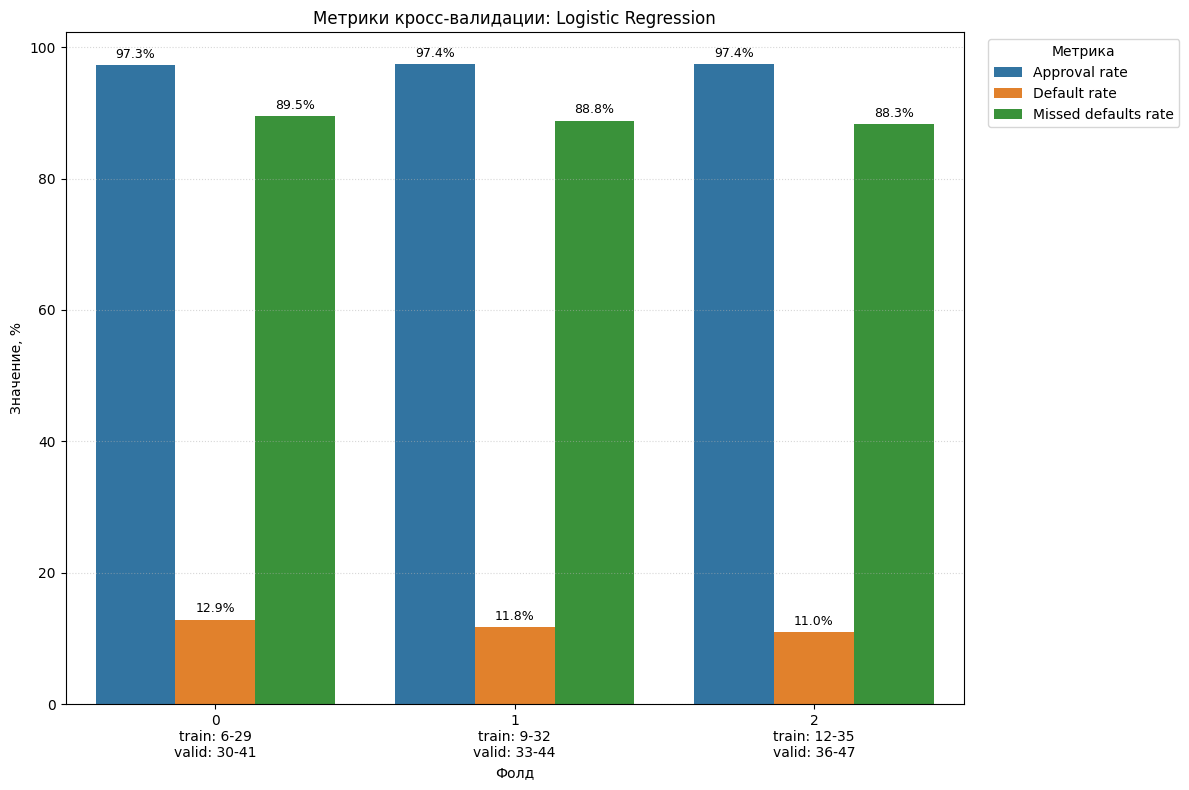

In [151]:
plot_score_by_folds(logreg_base_result, model_name='Logistic Regression')

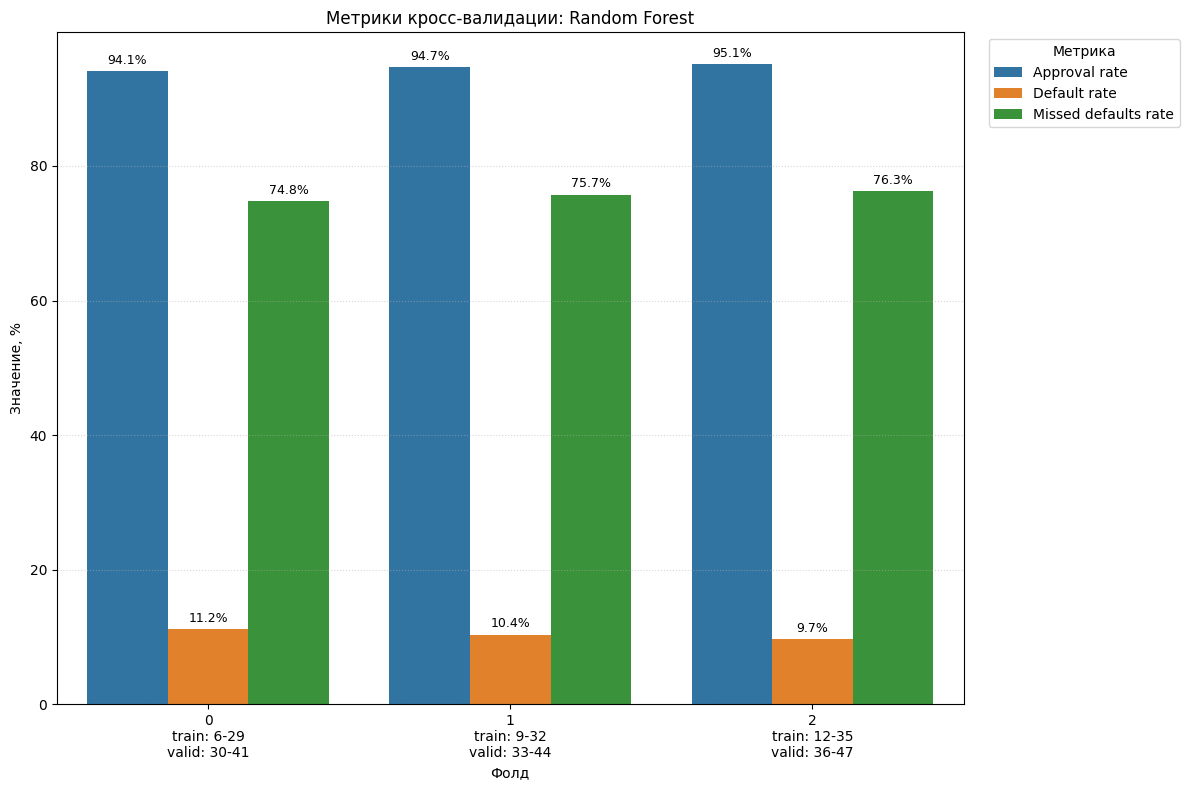

In [152]:
plot_score_by_folds(random_forest_base_result, model_name='Random Forest')

In [153]:
# сохранение результата
models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_base_result,
        'Logistic Regression',
    ),
    summarize_cv_metrics(
        random_forest_base_result,
        'Random Forest',
    ),
], ignore_index=True)
models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.973550,0.118882,0.888763,0.872254,0.548714
1,Random Forest,3,0.946281,0.103984,0.756053,0.879711,0.609366


#### Выводы по работе базовых моделей

- по метрике Approval rate базовые модели показывают высокие результаты (более 90%). Модели предсказывают высокую долю клиентов, которые являются надежными. Это можно объяснить тем, что надежных клиентов существенное большинство и, даже при плохой способности предсказывать, у модели на несбалансированных классах может быть высоким этот показатель.
- по метрикам default rate и missed defaults значения на порядок выше требований. Это связано с тем, что ненадежных клиентов достаточно мало и модели на несбалансированных классах плохо предсказывают редкий класс дефолтов

### Работа с дисбалансом классов

- в исходных данных дисбаланс умененный (миноритарного класса более 10%)
- применяется подход генерации синтетики


In [154]:
y_train.value_counts() / len(y_train)

target
0    0.838984
1    0.161016
Name: count, dtype: float64

In [155]:
# генерация синтетических объектов редкого класса
smote_sampler = SMOTE(
    k_neighbors=3,
    sampling_strategy=0.5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)


Обновленные пайплайны с балансировщиками

In [156]:
# логрег
logreg_base_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

In [157]:
# случайный лес
random_forest_base_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, max_depth=50))
])

Обучение 

In [158]:
logreg_base_balanced_result = cross_valid_cycle(
    model=logreg_base_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarn

In [159]:
random_forest_balanced_result = cross_valid_cycle(
    model=random_forest_base_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/User

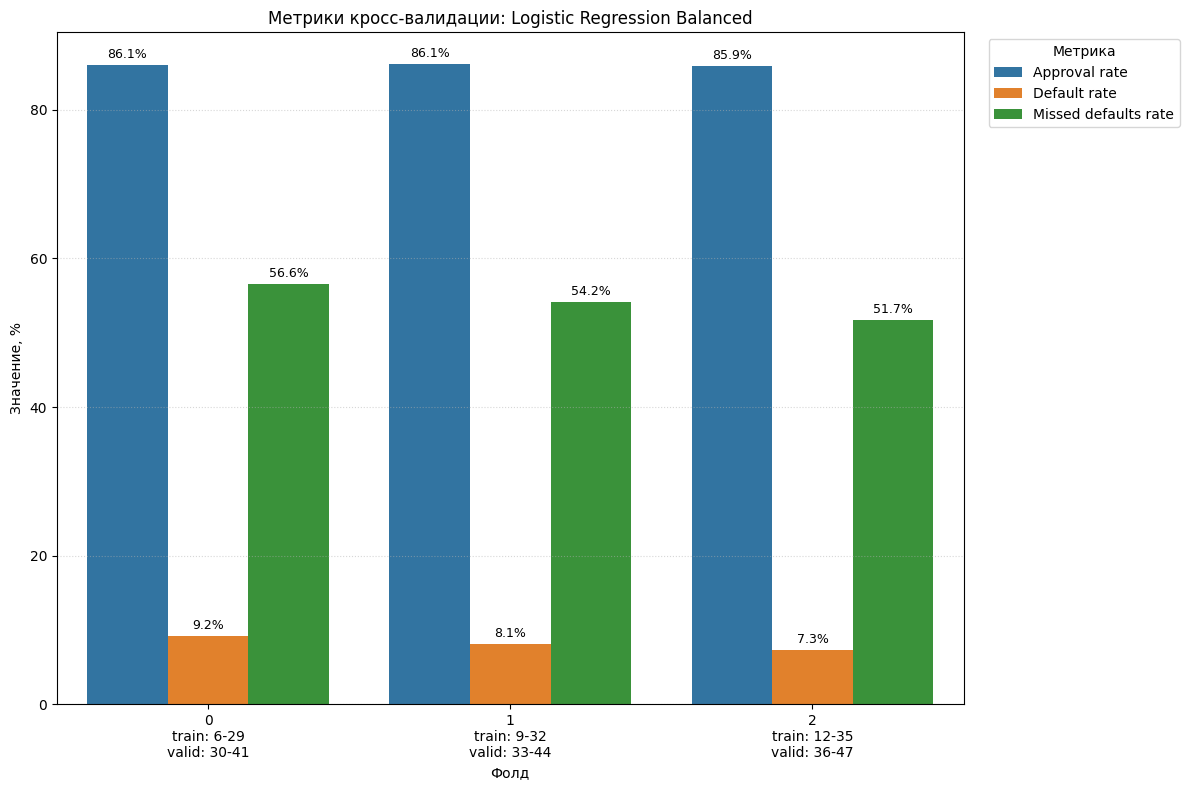

In [160]:
plot_score_by_folds(logreg_base_balanced_result, model_name='Logistic Regression Balanced')

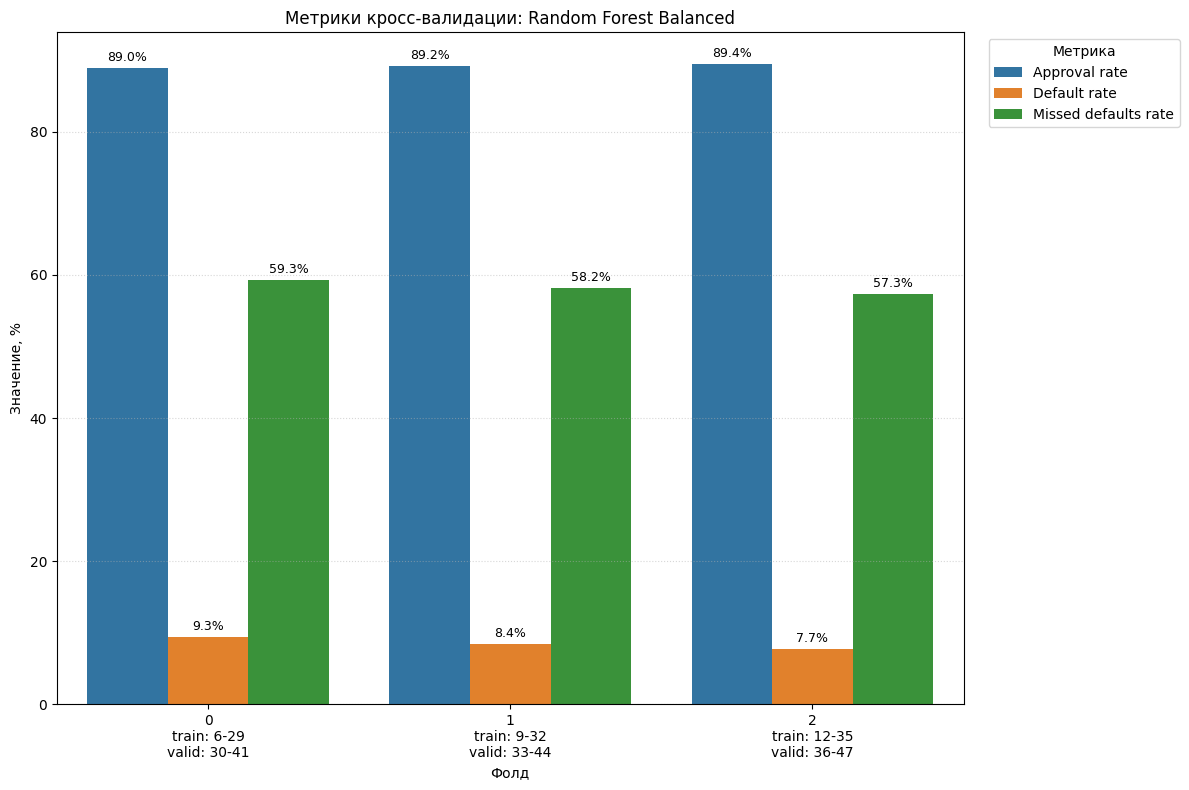

In [161]:
plot_score_by_folds(random_forest_balanced_result, model_name='Random Forest Balanced')

In [162]:
balanced_models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_base_balanced_result,
        'Logistic Regression Balanced',
    ),
    summarize_cv_metrics(
        random_forest_balanced_result,
        'Random Forest Balanced',
    ),
], ignore_index=True)

balanced_models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression Balanced,3,0.860152,0.082139,0.541582,0.849012,0.683038
1,Random Forest Balanced,3,0.892039,0.085071,0.582361,0.870467,0.677974


In [163]:
models_summary = pd.concat([
    models_summary,
    balanced_models_summary,
], ignore_index=True)

models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.973550,0.118882,0.888763,0.872254,0.548714
1,Random Forest,3,0.946281,0.103984,0.756053,0.879711,0.609366
2,Logistic Regression Balanced,3,0.860152,0.082139,0.541582,0.849012,0.683038
3,Random Forest Balanced,3,0.892039,0.085071,0.582361,0.870467,0.677974


Анализ:
- балансировка положительно повлияла на способность моделей выявлять редкий класс. Значения усредненных метрик default_rate и missed_defaults_rate существенно снизились. default_rate снизился на ~20% для обеих моделей, missed_defaults_rate снизился на ~30%
- модель стала чаще ошибаться в предсказаниях более распространенного класса, что выражается в снижении метрики approval_rate на ~10%
- в целом эффект от балансировки стоит рассматривать как положительный: для решения поставленной бизнесом задачи гораздо важнее обнаруживать редкий класс

---
## 6. Подбор гиперпараметров модели

### Оптимизация параметров для RandomForestClassifier

In [ ]:
def objective_random_forest(trial):
    """
    Функция-цель для оптимизации параметров случайного леса
    """

    # Пространство поиска
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 50),
        "max_depth": trial.suggest_int("max_depth", 20, 60),   # глубина дерева
        "min_samples_split": trial.suggest_int("min_samples_split", 40, 100), # минимальное число объектов для разбиения
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50), # минимальное число объектов в листе
        "criterion": trial.suggest_categorical("criterion", ['entropy']),  # функция качества
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.03),
        'class_weight':  trial.suggest_categorical("class_weight", ['balanced_subsample']), 
    }

    # случайный лес
    pipeline = ImbPipeline(steps=[
        ('preproc', create_preprocessing_pipeline()),
        ('model', RandomForestClassifier(**params, random_state=RANDOM_SEED, n_jobs=-1))
    ])

    scores = cross_valid_cycle(
        model=pipeline, 
        tscv=tscv, 
        X=X_train,
        y=y_train,
        groups=train_groups,
    )
    
    
    return mean_missed_defaults_rate(scores)


In [79]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_random_forest = optuna.create_study(direction="minimize", sampler=sampler) 

[I 2026-06-12 21:30:04,216] A new study created in memory with name: no-name-02a8e4d0-5cf6-43e6-9fb0-1e207ed2b6bb


In [80]:
# запуск оптимизации
study_random_forest.optimize(objective_random_forest, n_trials=30, show_progress_bar=True) 

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-12 21:30:09,188] Trial 0 finished with value: 0.1325621692973006 and parameters: {'n_estimators': 44, 'max_depth': 58, 'min_samples_split': 79, 'min_samples_leaf': 34, 'criterion': 'entropy', 'ccp_alpha': 0.004680559213273095, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.1325621692973006.
[I 2026-06-12 21:30:12,253] Trial 1 finished with value: 0.1266227497513667 and parameters: {'n_estimators': 24, 'max_depth': 22, 'min_samples_split': 90, 'min_samples_leaf': 34, 'criterion': 'entropy', 'ccp_alpha': 0.021242177333881365, 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.1266227497513667.
[I 2026-06-12 21:30:14,340] Trial 2 finished with value: 0.12800189217278576 and parameters: {'n_estimators': 11, 'max_depth': 59, 'min_samples_split': 87, 'min_samples_leaf': 18, 'criterion': 'entropy', 'ccp_alpha': 0.005454749016213018, 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.1266227497513667.
[I 2026-06-12 21:30:18,1

In [81]:
display(study_random_forest.best_params, study_random_forest.best_value)

{'n_estimators': 40,
 'max_depth': 34,
 'min_samples_split': 79,
 'min_samples_leaf': 15,
 'criterion': 'entropy',
 'ccp_alpha': 0.0037562104098805317,
 'class_weight': 'balanced_subsample'}

0.11057965523908693

In [167]:
random_forest_opt_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED, **study_random_forest.best_params))
])

In [168]:
random_forest_opt_result = cross_valid_cycle(
    model=random_forest_opt_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

### Оптимизация параметров для LogReg

In [ ]:
def objective_logreg(trial):
    """
    Функция-цель для оптимизации параметров логистической регрессии
    """

    # Пространство поиска
    params = {
        "C": trial.suggest_float("C", 0.001, 100, log=True), 
        "l1_ratio": trial.suggest_float("l1_ratio", 0, 1),
        'class_weight': trial.suggest_categorical("class_weight", ['balanced']), 
        'penalty': trial.suggest_categorical('penalty', ['l2']) 
    }

    pipeline = ImbPipeline(steps=[
        ('preproc', create_preprocessing_pipeline()),
        ('model', LogisticRegression(**params, random_state=RANDOM_SEED, n_jobs=-1))
    ])

    scores = cross_valid_cycle(
        model=pipeline, 
        tscv=tscv, 
        X=X_train,
        y=y_train,
        groups=train_groups,
    )
    
    
    return mean_missed_defaults_rate(scores)

In [85]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_logreg = optuna.create_study(direction="minimize", sampler=sampler)

[I 2026-06-12 21:33:38,746] A new study created in memory with name: no-name-ef26d53f-ac14-4185-8998-08b068351700


In [86]:
# запуск оптимизации
study_logreg.optimize(objective_logreg, n_trials=30, show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: d

[I 2026-06-12 21:33:43,719] Trial 0 finished with value: 0.21611617584693668 and parameters: {'C': 0.07459343285726547, 'l1_ratio': 0.9507143064099162, 'solver': 'lbfgs', 'class_weight': 'balanced', 'penalty': 'l2'}. Best is trial 0 with value: 0.21611617584693668.


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/

[I 2026-06-12 21:33:45,785] Trial 1 finished with value: 0.2067822916033797 and parameters: {'C': 0.006026889128682512, 'l1_ratio': 0.15599452033620265, 'solver': 'saga', 'class_weight': 'balanced', 'penalty': 'l2'}. Best is trial 1 with value: 0.2067822916033797.


...

[I 2026-06-12 21:35:50,396] Trial 27 finished with value: 0.20285584266997603 and parameters: {'C': 0.0031444885165195567, 'l1_ratio': 0.6228397219373537, 'solver': 'lbfgs', 'class_weight': 'balanced', 'penalty': 'l2'}. Best is trial 11 with value: 0.19114458854838715.


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.

[I 2026-06-12 21:35:54,761] Trial 28 finished with value: 0.19081342447762875 and parameters: {'C': 0.0010304683182957577, 'l1_ratio': 0.1877564703696277, 'solver': 'lbfgs', 'class_weight': 'balanced', 'penalty': 'l2'}. Best is trial 28 with value: 0.19081342447762875.


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.

[I 2026-06-12 21:35:59,340] Trial 29 finished with value: 0.21553868391236372 and parameters: {'C': 0.05758018879694845, 'l1_ratio': 0.20183147566897683, 'solver': 'lbfgs', 'class_weight': 'balanced', 'penalty': 'l2'}. Best is trial 28 with value: 0.19081342447762875.


In [87]:
display(study_logreg.best_params, study_logreg.best_value)

{'C': 0.0010304683182957577,
 'l1_ratio': 0.1877564703696277,
 'solver': 'lbfgs',
 'class_weight': 'balanced',
 'penalty': 'l2'}

0.19081342447762875

In [169]:
logreg_opt_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', LogisticRegression(random_state=RANDOM_SEED, **study_logreg.best_params))
])

In [170]:
logreg_opt_result = cross_valid_cycle(
    model=logreg_opt_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: d

#### Сравнение моделей

In [171]:
optimized_models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_opt_result,
        'Logistic Regression Opt',
    ),
    summarize_cv_metrics(
        random_forest_opt_result,
        'Random Forest Opt',
    ),
], ignore_index=True)



In [172]:
models_summary = pd.concat([models_summary, optimized_models_summary], ignore_index=True)
models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.973550,0.118882,0.888763,0.872254,0.548714
1,Random Forest,3,0.946281,0.103984,0.756053,0.879711,0.609366
2,Logistic Regression Balanced,3,0.860152,0.082139,0.541582,0.849012,0.683038
3,Random Forest Balanced,3,0.892039,0.085071,0.582361,0.870467,0.677974
4,Logistic Regression Opt,3,0.675165,0.040769,0.210233,0.750401,0.767157
5,Random Forest Opt,3,0.631620,0.022147,0.106482,0.733912,0.801769


#### Анализ

Подбор гиперпараметров позволил существенно снизить метрики: default_rate и missed_defaults_rate. 
- default_rate для моделей в диапазоне 2-4%, что ниже показателей базовых моделей в 5-6 раз. 
- missed_defaults_rate для LogReg снижено в 4,7 раза, для Random Forest метрика снижена в 7 раз относительно базовой модели

Можно сделать вывод, что оптимизация параметров позволила моделям лучше определять редкий класс.

Метрика approval_rate при этом снизилась примерно на 30% относительно базовых моделей. Это можно объяснить тем, что модели стали чаще ошибаться в предсказании более распространенного класса.

### Применение оптимальных параметров + балансировка

In [173]:
random_forest_opt_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED, **study_random_forest.best_params))
])
random_forest_opt_balanced_result = cross_valid_cycle(
    model=random_forest_opt_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/User

In [174]:
logreg_opt_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', LogisticRegression(random_state=RANDOM_SEED, **study_logreg.best_params))
])
logreg_opt_balanced_result = cross_valid_cycle(
    model=logreg_opt_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: 

### Выбор лучшей модели

In [175]:
optimized_balanced_models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_opt_balanced_result,
        'Logistic Regression Opt Balanced',
    ),
    summarize_cv_metrics(
        random_forest_opt_balanced_result,
        'Random Forest Opt Balanced',
    ),
], ignore_index=True)

In [176]:
models_summary = pd.concat([models_summary, optimized_balanced_models_summary], ignore_index=True)


In [177]:
models_summary.sort_values(by=['accuracy', 'roc_auc'], ascending=True)

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
5,Random Forest Opt,3,0.631620,0.022147,0.106482,0.733912,0.801769
7,Random Forest Opt Balanced,3,0.634704,0.022815,0.110872,0.735992,0.801029
4,Logistic Regression Opt,3,0.675165,0.040769,0.210233,0.750401,0.767157
6,Logistic Regression Opt Balanced,3,0.683548,0.042509,0.222151,0.755729,0.765133
2,Logistic Regression Balanced,3,0.860152,0.082139,0.541582,0.849012,0.683038
3,Random Forest Balanced,3,0.892039,0.085071,0.582361,0.870467,0.677974
0,Logistic Regression,3,0.973550,0.118882,0.888763,0.872254,0.548714
1,Random Forest,3,0.946281,0.103984,0.756053,0.879711,0.609366


In [178]:
# лучшая модель
best_model = RandomForestClassifier(**study_random_forest.best_params, random_state=RANDOM_SEED)


Итог:

- по метрикам accuracy,	roc_auc была отобрана лучшая модель --  случайный лес с подобранными с помощью Optuna параметрами


---
## 7. Калибровка модели и пересчёт результатов

In [179]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    plt.figure(figsize=(8, 8))
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [180]:
def get_calib_metrics(y_test, model_probabilities, sort_by=['brier_score']):
    """Резельтат калибровки"""
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_test, y_proba),
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [ ]:
def get_calibrated_model(model, X_train, y_train, X_calib, y_calib, method='isotonic'):
    preprocessor = create_preprocessing_pipeline()
    preprocessor.fit(X_train, y_train)
    X_train_prep = preprocessor.transform(X_train)
    X_calib_prep = preprocessor.transform(X_calib)

    base_model = clone(model)
    base_model.fit(X_train_prep, y_train)

    calibrated_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model),   
        method=method,
        cv='prefit',                            
        n_jobs=-1
    )
    calibrated_model.fit(X_calib_prep, y_calib)

    return preprocessor, base_model, calibrated_model

In [182]:
# Обучение с калибровкой 
best_model_preprocessor, best_model, best_model_calibrated = get_calibrated_model(
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib, 
    y_calib=y_calib,
    method='isotonic',
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [183]:
X_test_prep = best_model_preprocessor.transform(X_test)

y_test_proba_calibrated = best_model_calibrated.predict_proba(X_test_prep)[:, 1]

y_test_proba = best_model.predict_proba(X_test_prep)[:, 1]

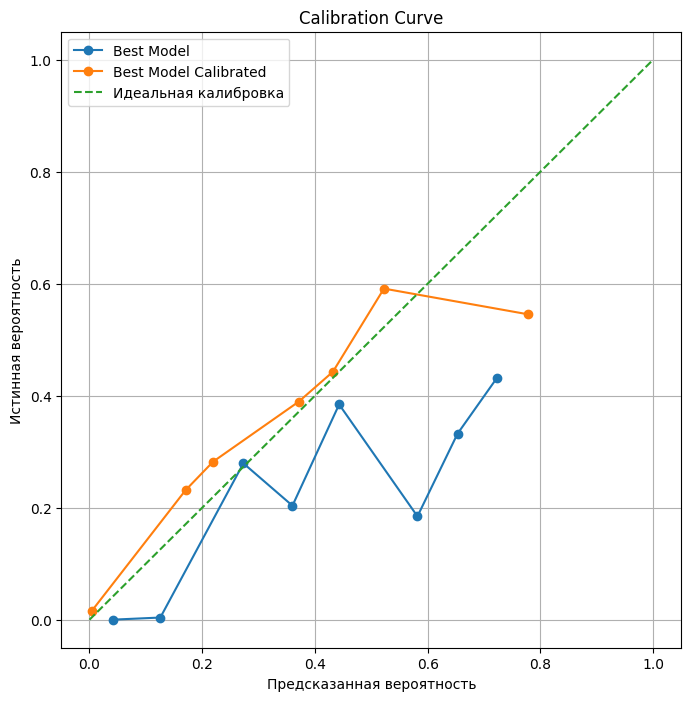

In [184]:
plot_calibration_curve(
    y_test, 
    [y_test_proba, y_test_proba_calibrated],
    names=['Best Model', 'Best Model Calibrated'],
    n_bins=10
)

In [185]:
model_probabilities = {
    'Best Model Uncalib': y_test_proba,
    'Best Model Calib': y_test_proba_calibrated,
}

In [186]:
get_calib_metrics(
    y_test,
    model_probabilities,
)


,model,brier_score
0,Best Model Calib,0.073781
1,Best Model Uncalib,0.103811


#### Анализ

- график калибровки показывает, что вероятности, предсказывемые моделью теперь гораздо лучше отражают реальные частоты, с которыми встречаются классы при различных порогах по вероятности 
- метрика калибровки brier_score - среднеквадратичная ошибка вероятности прогноза уменьшена на 30%, что подтверждает положительное влияние калибровки

### Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [188]:
def calc_metrics_threshold(proba, y_true, threshold):
    # pred = 1 (отказ), если вероятность дефолта > threshold
    pred_bad = proba > threshold
    pred_good = ~pred_bad
    
    # Доля одобренных 
    approval_rate = pred_good.mean()
    
    # Default rate: P(default | одобрен)
    n_approved = pred_good.sum()
    default_rate = y_true[pred_good].mean()
    
    # Missed defaults rate
    true_defaults = y_true == 1
    n_true_defaults = true_defaults.sum()
    if n_true_defaults == 0:
        missed_defaults_rate = np.nan
    else:
        fn = (pred_good & true_defaults).sum()
        missed_defaults_rate = fn / n_true_defaults
    
    return approval_rate, default_rate, missed_defaults_rate

In [ ]:
# Предсказания на калибровочном множестве
X_calib_prep = best_model_preprocessor.transform(X_calib)
proba_calib = best_model_calibrated.predict_proba(X_calib_prep)[:, 1]
y_true = y_calib.values.ravel() if hasattr(y_calib, 'values') else y_calib



# Поиск порога
thresholds = np.unique(proba_calib)  # все уникальные значения вероятностей
results = []

for th in thresholds:
    ar, dr, mdr = calc_metrics_threshold(proba_calib, y_true, th)
    if ar >= 0.65 and dr <= 0.02 and mdr <= 0.04:
        results.append((th, ar, dr, mdr))


best_th, best_ar, best_dr, best_mdr = max(results, key=lambda x: x[1])
print(f"Оптимальный порог: {best_th:.4f}")
print(f"Approval rate:        {best_ar:.3f}")
print(f"Default rate:         {best_dr:.4f}")
print(f"Missed defaults rate: {best_mdr:.4f}")

Оптимальный порог: 0.0657
Approval rate:        0.664
Default rate:         0.0060
Missed defaults rate: 0.0394


#### Итог
- подобран оптимальный порог, позволяющий удовлетворить требования по точности модели: 
    - Approval rate не менее 65%;
    - Default rate не более 2%;
    - Missed defaults rate не более 4%.

---
## 8. Анализ матрицы ошибок

In [194]:
# Предсказания на калибровочном множестве
X_calib_prep = best_model_preprocessor.transform(X_calib)
proba_calib = best_model_calibrated.predict_proba(X_calib_prep)[:, 1]
y_calib_true = y_calib.values.ravel() if hasattr(y_calib, 'values') else y_calib

# оптимальный порог
threshold = best_th
y_calib_pred = (proba_calib > threshold).astype(int)

# Предсказания на тестовом множестве
X_test_prep = best_model_preprocessor.transform(X_test)
proba_test = best_model_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_test_pred = (proba_test > threshold).astype(int)

In [228]:
def plot_confusion_matrices(y_true_cal, y_pred_cal, y_true_test, y_pred_test, class_names=['Норм - 0', 'Дефолт - 1']):
    fig, axes = plt.subplots(1, 2)

    # Матрица на калибровочных данных
    cm_cal = confusion_matrix(y_true_cal, y_pred_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, display_labels=class_names)
    disp_cal.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Матрица ошибок - Калибровочные данные')

    # Матрица на тестовых данных
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
    disp_test.plot(ax=axes[1], cmap='Blues', values_format='d')
    axes[1].set_title('Матрица ошибок -  Тестовые данные')

    plt.tight_layout()
    plt.show()

    return cm_cal, cm_test

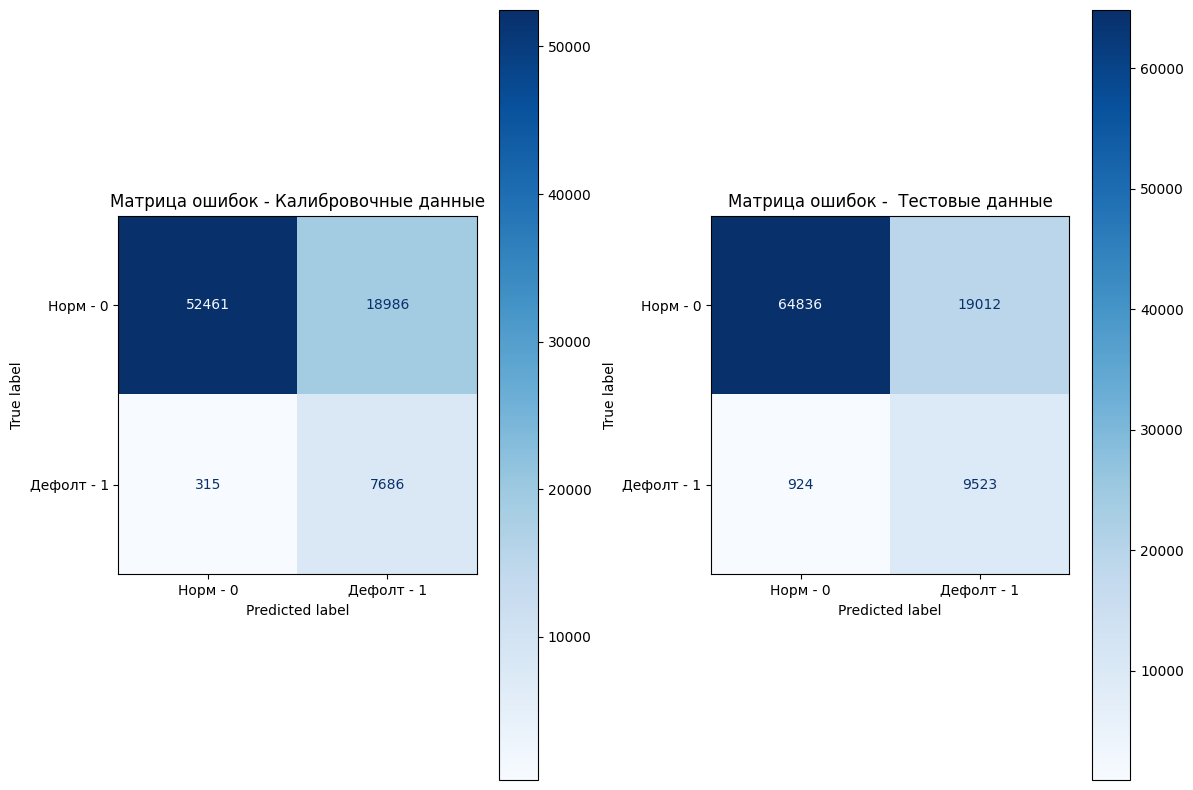

(array([[52461, 18986],
        [  315,  7686]]),
 array([[64836, 19012],
        [  924,  9523]]))

In [229]:
cm_cal, cm_test = plot_confusion_matrices(y_calib_true, y_calib_pred, y_test_true, y_test_pred)
cm_cal, cm_test

In [230]:
print('Калибровка: ')
print(classification_report(y_calib_true, y_calib_pred, target_names=['Норм', 'Дефолт']))

Калибровка: 
              precision    recall  f1-score   support

        Норм       0.99      0.73      0.84     71447
      Дефолт       0.29      0.96      0.44      8001

    accuracy                           0.76     79448
   macro avg       0.64      0.85      0.64     79448
weighted avg       0.92      0.76      0.80     79448



In [231]:
print('Тест: ')
print(classification_report(y_test_true, y_test_pred, target_names=['Норм', 'Дефолт']))

Тест: 
              precision    recall  f1-score   support

        Норм       0.99      0.77      0.87     83848
      Дефолт       0.33      0.91      0.49     10447

    accuracy                           0.79     94295
   macro avg       0.66      0.84      0.68     94295
weighted avg       0.91      0.79      0.82     94295



In [232]:
def calc_business_metrics(y_true, y_pred):
    """Расчёт approval rate, default rate, missed defaults rate."""
    n_total = len(y_true)
    n_approved = (y_pred == 0).sum()
    n_defaults = (y_true == 1).sum()

    ar = n_approved / n_total
    dr = y_true[y_pred == 0].mean() if n_approved > 0 else np.nan
    mdr = ((y_pred == 0) & (y_true == 1)).sum() / n_defaults if n_defaults > 0 else np.nan
    return ar, dr, mdr

In [233]:
ar_cal, dr_cal, mdr_cal = calc_business_metrics(y_calib_true, y_calib_pred)
ar_test, dr_test, mdr_test = calc_business_metrics(y_test_true, y_test_pred)

print("\n--- Сравнение ключевых бизнес метрик ---")
print(f"{'Метрика':<25} {'Калибровка':>15} {'Тест':>15}")
print(f"{'Approval Rate':<25} {ar_cal:>15.3f} {ar_test:>15.3f}")
print(f"{'Default Rate':<25} {dr_cal:>15.4f} {dr_test:>15.4f}")
print(f"{'Missed Defaults Rate':<25} {mdr_cal:>15.4f} {mdr_test:>15.4f}")


--- Сравнение ключевых бизнес метрик ---
Метрика                        Калибровка            Тест
Approval Rate                       0.664           0.697
Default Rate                       0.0060          0.0141
Missed Defaults Rate               0.0394          0.0884


#### Итог:

- матрица ошибок имеет схожий вид на калибровке и тесте. Ключевые для бизнеса ошибки сведены к минимуму: предсказания отсутствия дефолта при истинном дефолте малочисленны.
- модель ведет себя достаточно стабильно: на тестовых данных ключевые метрики показывают умеренное ухудшение по сравнению с калибровкой, но по-прежнему удовлетворяют требованиям 

---
## 9. Фиксирование итоговой модели

Лучшая модель: 
- случайный лес с оптимизированными на тренировочной выборке параметрами с помощью пайплайна с кросс валидацией
- на калибровочной выборке подобрано значение вероятности, которое позволяет достичь целевых показателей по ключевым метрикам


In [234]:
class ThresholdCalibratedClassifier(BaseEstimator, ClassifierMixin):
    """
    Принимает уже обученный препроцессор, калиброванную модель и порог.
    Метод predict возвращает 1 если откалиброванная вероятность > threshold,
    иначе 0.
    """
    def __init__(self, preprocessor, calibrated_model, threshold):
        self.preprocessor = preprocessor
        self.calibrated_model = calibrated_model
        self.threshold = threshold

    def predict_proba(self, X):
        """Возвращает вероятности класса 1 (дефолт)."""
        X_prep = self.preprocessor.transform(X)
        return self.calibrated_model.predict_proba(X_prep)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba > self.threshold).astype(int)


In [235]:
final_model = ThresholdCalibratedClassifier(
    preprocessor=best_model_preprocessor,
    calibrated_model=best_model_calibrated,
    threshold=best_th
)
final_model

ThresholdCalibratedClassifier(calibrated_model=CalibratedClassifierCV(cv='prefit',
                                                                      estimator=FrozenEstimator(estimator=RandomForestClassifier(ccp_alpha=0.0037562104098805317,
                                                                                                                                 class_weight='balanced_subsample',
                                                                                                                                 criterion='entropy',
                                                                                                                                 max_depth=34,
                                                                                                                                 min_samples_leaf=15,
                                                                                                                                 min_samples_split=79,
                                                                                                                                 n_estimators=40,
                                                                                                                                 random_state=42)),
                                                                      method='isotonic',
                                                                      n_jobs=-1),
                              prepro...
                                                                            Pipeline(steps=[('imputer',
                                                                                             SimpleImputer(fill_value=0,
                                                                                                           strategy='constant')),
                                                                                            ('scaler',
                                                                                             MinMaxScaler())]),
                                                                            <function select_num_special_zero at 0x328086b80>),
                                                                           ('num_classic_pipeline',
                                                                            Pipeline(steps=[('imputer',
                                                                                             SimpleImputer(strategy='median')),
                                                                                            ('scaler',
                                                                                             RobustScaler())]),
                                                                            <function select_num_classic at 0x329e030d0>)]),
                              threshold=np.float64(0.06571428571428571))

---
## 10. Анализ важности признаков


In [236]:
rf_model = final_model.calibrated_model.estimator.estimator
preprocessor = final_model.preprocessor

In [237]:
importances = rf_model.feature_importances_
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(len(importances))]

# Сортируем по убыванию
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_names = feature_names[indices]

In [238]:
top_n = 20
print(f"Топ-{top_n} признаков по важности для модели RandomForest:")
for i in range(min(top_n, len(sorted_names))):
    print(f"{sorted_names[i]:45s} {sorted_importances[i]:.4f}")

Топ-20 признаков по важности для модели RandomForest:
num_classic_pipeline__income_spend_ratio_3m   0.4479
num_classic_pipeline__MCC_5411_sum_3m         0.0659
num_classic_pipeline__доход                   0.0650
num_classic_pipeline__MCC_3990_sum_3m         0.0526
num_classic_pipeline__возраст                 0.0505
num_classic_pipeline__MCC_другое_sum_3m       0.0461
num_classic_pipeline__MCC_5722_sum_3m         0.0431
num_classic_pipeline__MCC_5812_sum_3m         0.0411
num_classic_pipeline__MCC_5300_sum_3m         0.0357
num_classic_pipeline__MCC_4900_sum_3m         0.0304
num_classic_pipeline__rating_mean_6m          0.0234
num_classic_pipeline__MCC_другое_sum_6m       0.0204
num_classic_pipeline__MCC_3990_sum_6m         0.0146
num_classic_pipeline__MCC_5300_sum_6m         0.0109
num_classic_pipeline__MCC_5814_sum_3m         0.0097
num_classic_pipeline__кредитный_рейтинг       0.0092
num_classic_pipeline__MCC_5814_sum_6m         0.0082
num_classic_pipeline__MCC_4900_sum_6m        

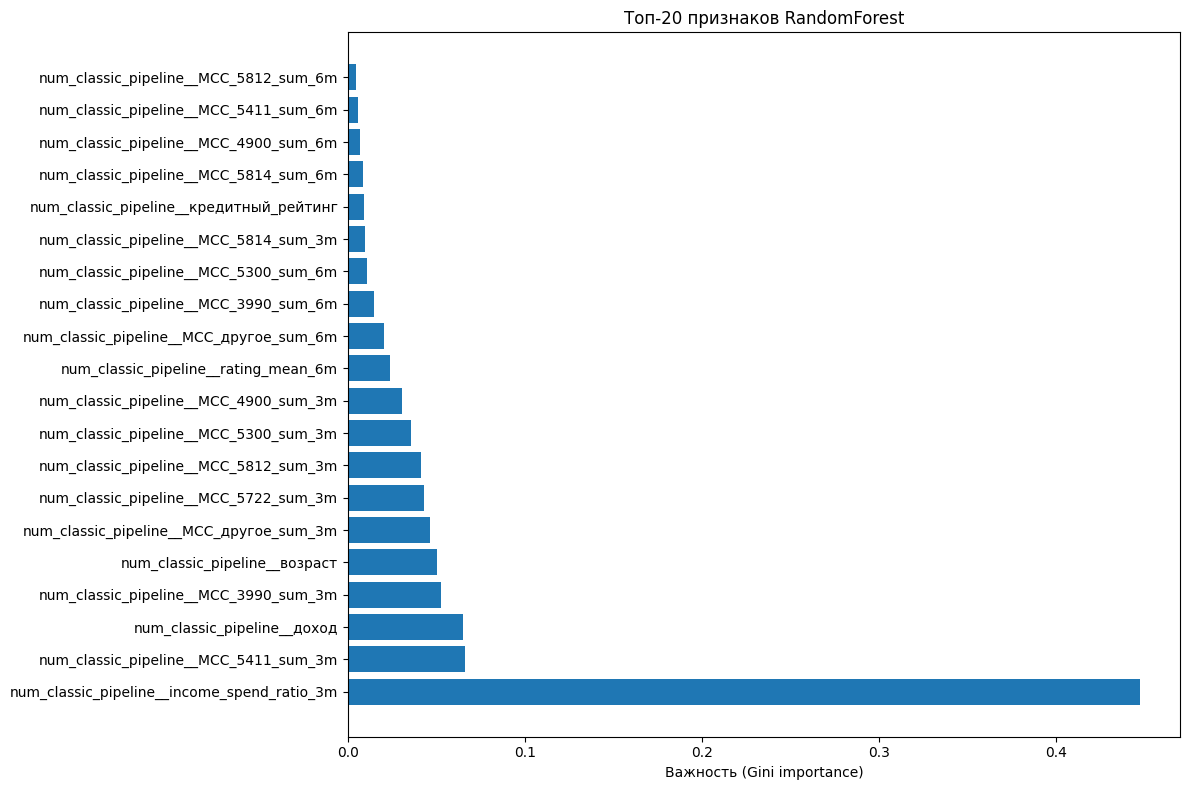

In [ ]:
plt.barh(range(top_n), sorted_importances[:top_n][::-1])
plt.yticks(range(top_n), sorted_names[:top_n][::-1])
plt.xlabel('Важность (Gini importance)')
plt.title(f'Топ-{top_n} признаков RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

### Цель и задачи исследования.

Целью исследования было построение модели поведенческого скоринга для предсказания по историческим данным вероятности дефолта клиента в ближайшие 12 месяцев

Среди задач можно отметить:
- загрузка датасета
- исследовательский анализ данных
- формирования итоговой таблицы
- обучение базовых моделей: логичстической регрессии и случайного леса
- обработка дисбаланса классов целевой переменной и оптимизация параметров моделей
- проведение сравнительного анализа и выбор лучшей модели 
- калибровка лучшей модели и выбор оптимального порога по вероятности для предсказания модели
- проверка выполнения требований заказчика по ключевым метрикам на тестовых данных, оценка стабильности модели 
- оценка важности признаков

###  Подготовка данных и выборок.

#### ИАД 

#### Общие сведения

Данные представлены в виде 8 таблиц:
- Данные о просрочке платежа: loan_payment_credit
- Месячные транзакции клиента: transactions
- Описание клиента на момент регистрации в банке: client_description
- Описание кредита: credit_description
- Данные о наличии ипотеки: mortgage_presence
- Данные о кредитном рейтинге клиента: credit_rating
- Данные о макроэкономических показателях России: macro_data
- Данные о дате проведения поведенческого скоринга: cohort_grid

Типы данных соотвествуют описанию. 

#### Пропуски, дубли

- явных и неявных пропусков/дублей в данных не обнаружено


#### Анализ распределений

Количественные данные:
- loan_payment_credit: значение дней просрочек равномерно распределено по диапазону
- transactions: траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- client_description: по возрасту распределение равномерное
- client_description: наличие иждевенцев представлено в примерно равных долях 
- credit_description: по доходу и сумме кредита распределение равномерное 
- mortgage_presence: данные по наличию ипотеки принимают одно значнение - 1
- credit_rating: распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Выдвинуто предположение, что в происходило округление или имеются стандратные рейтинги для каких-то категорий граждан.
- macro_data: Распределение по учетной ставке несимметричное и имеет малый набор уникальных значений
- macro_data: По безработице распределение симметричное без выбросов
- macro_data: По инфляции распределение симметричное, есть выбросы 

Категориальные данные:
- loan_payment_credit: дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- client_description: по признаку семейного пложения дисбаланса нет 
- mortgage_presence: по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки


#### Анализ целевой переменной

- наблюдается дисбаланс классов. Для более точного прогноза модели предложено использовать балансировку


### Формирование итоговой таблицы

Данные из 8-ми указанных выше таблиц сведены в один датасет. 
Итоговая таблица представляет собой временной ряд: на каждый месяц в заданном промежутке времени имеются данные по активности пользователей и общие макроэкономические данные.
Таблица дополнена новыми признаками для каждого уникального клиента: средние расходы по категорям и отношение дохода к расходу за 3 последние месяца.

- таблица состоит из 29 столбцов-признаков, характеризующих клиентов и макроэкономическую ситуацию в стране 
- кроме того, таблица содержит: target - целевая переменная, score_date - дата оценки, ID - идентификатор пользователя

### Пайплайн предобработки 

Категориальные данные закодированы с помощью OneHot.
Признаки масштабированы.
Стоит заметить, что масштабирование и обработка выбросов не обязательны для обучения случайного леса. Это сделано для универсальности пайплайна.



### Поиск и настройка модели.

- данные разделены на три выборки: train/calib/test
- применена кросс валидация на трех фолдах с группировкой по месяцам 
- обучены две модели на базовых настройках: логистическая регрессия и случайный лес
- для обработки дисбаланса классов выбран метод генерации синтетики: дисбланс несильный и объектов миноритарного класса довольно много в выборке, поэтому подход позволяет сгенерировать довольно качественные объекты редкого класса. 
В результате балансировки ключевые метрики базовыз моделей существенно улучшаются, что подтверждает применимость подхода.
- проведена оптимизация параметров моделей с помощью библиотеки Optuna. Модели с оптимизированными параметрами существенно превосходят базовые модели по ключевым метрикам.
- проведен отбор лучшей модели: случайный лес после оптимизации параметров


4. Калибровка вероятностей.
- к лучшей модели с предыдущего этапа применена калибровка. 
- график калибровочных кривых и оценка бриера позволяет сделать вывод: калиброванная модель лучше отражает реальную частоту появления целевого класса в данных. То есть калибровка проведена корректно 

5. Оптимизация бизнес-порога.
- проведен подбор порога по вероятности предсказания целевого класса. Полученные ключевые метрики удовлетворяют требованиям заказчика.


6. Анализ важности признаков.
наиболее важными признаками модели являются: 
- соотношение доход/расход за 3 последних месяца. Изменение этого показателя может быть интерпретирован как сигнал, что клиент начал тратить больше, чем зарабатывает и вероятнее всего не может закрыть платеж по кредиту в ближайщем будущем.
- доход клиента - ожидаемо довольно важный показатель. Можно предположить, что чем ниже доход, тем меньше веротность выплаты по кредиту
- траты за последние 3 месяца также входят в топ по важности. Рост трат может быть сигналом для прогноза дефолта

7. Финальный пайплайн.
Итоговый пайплайн состоит из: 
- пайплайна предобработки данных с обработкой категоральных данных и обработкой пропусков, масштабированием признаков  
- модели случайного леса обученного на train с кросс валидацией на 3х фолдах и с подобранными гиперпараметрами. 
- Модель откалибрована и содердит порог по вероятности, соответствующий бизнес требованиям.

8. Основные выводы и рекомендации для бизнеса.

Разработанная модель оптимизирована по гиперпараметрам, показывает стабильное качество предсказаний, удовлетворяет бизнес требованиям по качеству. Модель может быть рекомендована к использованию для предсказания вероятности дефолта клиентов на горизонте 12 месяцев.
Как показал проведенный аналих, стоит обращать внимание на соотношение доход/расход за последние несколько месяцев, чтобы предсказать дефолт клиента ближайшее время.